In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler ,OrdinalEncoder , FunctionTransformer,LabelEncoder
from sklearn.model_selection import train_test_split, KFold, cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
import xgboost
import warnings
warnings.filterwarnings('ignore')



| العمود                   | النوع         | الوصف                                                                                                                                  |
|--------------------------|---------------|----------------------------------------------------------------------------------------------------------------------------------------|
| **CAMIS**                | int           | رقم التعريف الفريد للمطعم (Citywide Automated Management Information System)                                                          |
| **DBA**                  | نصي/فئوي     | اسم المطعم المسجل (Doing Business As)                                                                                                 |
| **BORO**                 | فئوي         | الحي/البلدة (Manhattan, Bronx, Queens, Brooklyn, Staten Island)                                                                         |
| **BUILDING**             | نصي         | رقم المبنى أو وحدة المبنى                                                                                                               |
| **STREET**               | نصي         | اسم الشارع                                                                                                                              |
| **ZIPCODE**              | نصي/فئوي    | الرمز البريدي للمطعم                                                                                                                    |
| **PHONE**                | نصي         | رقم هاتف المطعم                                                                                                                         |
| **CUISINE DESCRIPTION**  | فئوي         | نوع المطبخ (مثلاً Italian, Chinese, Mexican, American, …)                                                                               |
| **INSPECTION DATE**      | تاريخي        | تاريخ إجراء التفتيش على المطعم (YYYY-MM-DD)                                                                                             |
| **ACTION**               | نصي         | إجراء المتخذ بعد التفتيش (مثل “Violations were cited” أو “No violations were recorded”)                                                 |
| **VIOLATION CODE**       | نصي/فئوي    | رمز المخالفة حسب تصنيف دائرة الصحة                                                                                                      |
| **VIOLATION DESCRIPTION**| نصي         | وصف المخالفة التي سجّلها المفتّش (مثل “Evidence of rodents”, “Improper food storage”)                                                   |
| **CRITICAL FLAG**        | نصي/فئوي    | علامة ما إذا كانت المخالفة حرجة (Critical) أو لا                                                                                        |
| **SCORE**                | عددي         | مجموع نقاط المخالفات (0–100+)؛ كلما ارتفع العدد دلّ على مخالفات أكثر أو أشد                                                         |
| **GRADE**                | فئوي         | الدرجة الحرفية المحوّلة من SCORE (A/B/C) أو رموز خاصة:  
|                          |               | • **P** = Pass (score = 0)  
|                          |               | • **A** (1–13), **B** (14–27), **C** (≥ 28)  
|                          |               | • **Z** = No Grade Given  
|                          |               | • **N** = Not Yet Graded                                                                                                               |
| **GRADE_MISSING**        | ثنائي (0/1)  | علمّ (flag) يوضح ما إذا كانت قيمة GRADE مفقودة (1 = مفقود، 0 = موجود)                                                                  |
| **RECORD DATE**          | تاريخي        | تاريخ تسجيل السجل في قاعدة البيانات                                                                                                     |
| **INSPECTION TYPE**      | نصي/فئوي    | نوع التفتيش (Initial, Re-inspection, Compliance, Smoke-Free Act, Trans Fat, Calorie Posting, …)                                        |
| **Latitude**             | عددي         | خط العرض الجغرافي لموقع المطعم                                                                                                          |
| **Longitude**            | عددي         | خط الطول الجغرافي لموقع المطعم                                                                                                          |
| **Community Board**      | فئوي/عددي    | رقم مجلس المجتمع البلدوري الذي يقع ضمنه المطعم                                                                                           |
| **Council District**     | فئوي/عددي    | رقم دائرة المجلس التشريعي المحلي                                                                                                        |
| **Census Tract**         | فئوي/عددي    | قطاع التعداد السكاني                                                                                                                    |
| **BIN**                  | فئوي/عددي    | Building Identification Number، معرّف فريد للمبنى                                                                                        |
| **BBL**                  | فئوي/عددي    | Borough-Block-Lot، معرّف القطعة الأرضية                                                                                                  |
| **NTA**                  | فئوي         | Neighborhood Tabulation Area، رمز إحصائي للحي                                                                                             |

  


In [7]:
data=pd.read_csv('/content/drive/MyDrive/DOHMH_New_York_City_Restaurant_Inspection_Results_20250707.csv',
                 parse_dates=['INSPECTION DATE','GRADE DATE'])

# EDA

In [8]:
data.shape

(285749, 27)

In [9]:
data.head(10)

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location Point1
0,50144096,Respite Center/The Row Hotel,Manhattan,700,8 AVENUE,10036.0,2015568312,NaN,1900-01-01,NaN,...,NaN,40.758656,-73.988738,105.0,3.0,11900.0,1024711.0,1.010168e+09,MN17,NaN
1,50163933,TULIPS AND SIPS,Brooklyn,366,BEDFORD AVENUE,11249.0,6467524448,NaN,1900-01-01,NaN,...,NaN,40.711753,-73.963045,301.0,34.0,54900.0,3063429.0,3.024430e+09,BK73,NaN
2,50170727,TACOS DEL BARRIO,Brooklyn,67,6 AVENUE,11217.0,3475825832,NaN,1900-01-01,NaN,...,NaN,40.680655,-73.974521,308.0,35.0,16100.0,3028037.0,3.011430e+09,BK64,NaN
3,50097845,BEE PATTERNS INC,Manhattan,220,EAST 42 STREET,10017.0,3474613000,NaN,1900-01-01,NaN,...,NaN,40.750249,-73.973256,106.0,4.0,8800.0,1037546.0,1.013158e+09,MN19,NaN
4,50167235,CUISINE & SPICES LINKS,Queens,3755,76TH ST,11372.0,8177038075,NaN,1900-01-01,NaN,...,NaN,40.747728,-73.889693,403.0,25.0,28700.0,4029881.0,4.012870e+09,QN28,NaN
5,41569764,BACCHUS,Brooklyn,409411,ATLANTIC AVENUE,NaN,7188521572,French,2022-11-28,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,3.000000e+00,NaN,NaN
6,50165007,DELI DELIGHTS & WAFFLE WONDERS CORP.,Manhattan,105,AVENUE A,10009.0,6467751963,NaN,1900-01-01,NaN,...,NaN,40.725847,-73.983692,103.0,2.0,3200.0,1005793.0,1.004348e+09,MN22,NaN
7,50171079,CATCH AIR,Brooklyn,608,SHEEPSHEAD BAY ROAD,11224.0,2295675485,NaN,1900-01-01,NaN,...,NaN,40.578956,-73.975182,313.0,48.0,35400.0,3346132.0,3.072790e+09,BK23,NaN
8,50171431,SOL ET SOLEIL LLC,Brooklyn,14,BUSHWICK AVENUE,11211.0,9178557438,NaN,1900-01-01,NaN,...,NaN,40.714319,-73.941880,301.0,34.0,49700.0,3068918.0,3.027660e+09,BK90,NaN
9,50157125,CORNER BAR/NINE ORCHARD EVENTS,Manhattan,54,CANAL STREET,10002.0,7204801963,NaN,1900-01-01,NaN,...,NaN,40.714904,-73.991970,103.0,1.0,1600.0,1003795.0,1.002940e+09,MN27,NaN


In [10]:
data.loc[89]

,89
CAMIS,50143667
DBA,LA NUEVA 90 BAKERY
BORO,Queens
BUILDING,3706
STREET,90TH ST
ZIPCODE,11372.0
PHONE,9176514591
CUISINE DESCRIPTION,Latin American
INSPECTION DATE,2024-04-23 00:00:00
ACTION,Violations were cited in the following area(s).


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285749 entries, 0 to 285748
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   CAMIS                  285749 non-null  int64         
 1   DBA                    285745 non-null  object        
 2   BORO                   285749 non-null  object        
 3   BUILDING               285152 non-null  object        
 4   STREET                 285743 non-null  object        
 5   ZIPCODE                282917 non-null  float64       
 6   PHONE                  285743 non-null  object        
 7   CUISINE DESCRIPTION    282380 non-null  object        
 8   INSPECTION DATE        285749 non-null  datetime64[ns]
 9   ACTION                 282380 non-null  object        
 10  VIOLATION CODE         280352 non-null  object        
 11  VIOLATION DESCRIPTION  280352 non-null  object        
 12  CRITICAL FLAG          285749 non-null  obje

In [12]:
data['NTA'].value_counts()

,count
NTA,
MN17,16354
MN13,8499
MN23,7989
MN24,7847
MN27,6577
...,...
BK93,113
SI08,93
MN99,81


In [13]:
data['CAMIS'].is_unique

False

In [14]:
data['BIN'].is_unique

False

In [15]:
data['BBL'].is_unique

False

In [16]:
data['BBL'].value_counts()

,count
BBL,
1.000000e+00,1923
4.000000e+00,1024
3.000000e+00,629
2.000000e+00,457
4.050190e+09,374
...,...
2.022151e+09,1
3.006120e+09,1
3.005960e+09,1


In [17]:
data.describe().T

,count,mean,min,25%,50%,75%,max,std
CAMIS,285749.0,47902129.400369,30075445.0,50000740.0,50084046.0,50121155.0,50172783.0,3849695.579647
ZIPCODE,282917.0,10706.539218,8512.0,10023.0,11101.0,11231.0,28217.0,595.035557
INSPECTION DATE,285749,2022-05-08 12:09:16.499585792,1900-01-01 00:00:00,2022-12-06 00:00:00,2023-12-07 00:00:00,2024-10-08 00:00:00,2025-07-03 00:00:00,NaN
SCORE,270454.0,24.486626,0.0,12.0,21.0,33.0,168.0,18.346809
GRADE DATE,129941,2023-10-20 19:21:27.972233472,2015-09-24 00:00:00,2023-01-03 00:00:00,2023-12-14 00:00:00,2024-10-15 00:00:00,2025-07-03 00:00:00,NaN
Latitude,285350.0,40.324223,0.0,40.685121,40.731779,40.761151,40.912822,4.033541
Longitude,285350.0,-73.208895,-74.249101,-73.988931,-73.956613,-73.895796,0.0,7.322279
Community Board,282042.0,254.660795,101.0,106.0,302.0,401.0,595.0,130.195297
Council District,282065.0,20.677624,1.0,4.0,20.0,34.0,51.0,15.751549
Census Tract,282065.0,29742.601163,100.0,8000.0,17200.0,42200.0,162100.0,31227.412646


In [18]:
data['BUILDING'].value_counts()

,count
BUILDING,
1,1372
200,919
2,841
25,775
55,691
...,...
17901,1
4103,1
19223,1


## حذف الأعمدة التي لا نحتاجها من البيانات

In [19]:
data.drop(['Location Point1','BIN','BBL'],axis=1,inplace=True)

In [20]:
info_df = pd.DataFrame(data.dtypes)

info_df['missing_val'] = data.isnull().sum()

info_df['missing_val_ratio'] = (info_df['missing_val'] / data.shape[0] * 100).round().astype(int)

info_df = info_df.rename(columns = {0:'data_type'})
info_df

,data_type,missing_val,missing_val_ratio
CAMIS,int64,0,0
DBA,object,4,0
BORO,object,0,0
BUILDING,object,597,0
STREET,object,6,0
ZIPCODE,float64,2832,1
PHONE,object,6,0
CUISINE DESCRIPTION,object,3369,1
INSPECTION DATE,datetime64[ns],0,0
ACTION,object,3369,1


In [21]:
df=data.copy()

### إنشاء أقنعة لتحديد أماكن القيم المفقودة وغير المفقودة في العمودين GRADE و GRADE DATE
حساب عدد الصفوف التي تحتوي على

- كلا القيمتين
-  على واحدة فقط

- تفتقد كلا القيمتين

In [22]:
has_grade      = df['GRADE'].notna()
has_gdate      = df['GRADE DATE'].notna()
missing_grade  = ~has_grade
missing_gdate  = ~has_gdate


total = len(df)

both_present      = (has_grade & has_gdate).sum()
only_grade        = (has_grade & missing_gdate).sum()
only_gdate        = (missing_grade & has_gdate).sum()
both_missing      = (missing_grade & missing_gdate).sum()


print(f"both exist(GRADE & GRADE DATE): {both_present} | {both_present/total*100:.2f}%")
print(f"just grade and not grade date  {only_grade} | {only_grade/total*100:.2f}%")
print(f"just grade date  and not grade {only_gdate} | {only_gdate/total*100:.2f}%")
print(f"both missing {both_missing} | {both_missing/total*100:.2f}%")


both exist(GRADE & GRADE DATE): 129941 | 45.47%
just grade and not grade date  8262 | 2.89%
just grade date  and not grade 0 | 0.00%
both missing 147546 | 51.63%


In [23]:
has_both = df['GRADE DATE'].notna() & df['INSPECTION DATE'].notna()

diff_dates = (df.loc[has_both, 'GRADE DATE'] != df.loc[has_both, 'INSPECTION DATE']).sum()
total = has_both.sum()

print(f"Out of {total} rows with both dates, number of mismatches: {diff_dates}")
print(f"Which corresponds to {(diff_dates/total*100):.2f}% difference")


Out of 129941 rows with both dates, number of mismatches: 0
Which corresponds to 0.00% difference


In [24]:
df.drop('GRADE DATE', axis=1, inplace=True)


In [25]:
df['GRADE'].value_counts()

,count
GRADE,
A,95127
B,16884
C,11550
N,8266
Z,5455
P,921


In [26]:
df['GRADE'].isna().sum()

np.int64(147546)

In [27]:

def score_to_grade(score):
    if pd.isna(score): return None
    if score == 0:    return 'P'
    if score <= 13:   return 'A'
    if score <= 27:   return 'B'
    return 'C'


mask = df['GRADE'].isna() & df['SCORE'].notna()
df.loc[mask, 'GRADE'] = df.loc[mask, 'SCORE'].apply(score_to_grade)


In [28]:
df['GRADE'].isna().sum()

np.int64(15282)

In [29]:
df['SCORE'].value_counts()

,count
SCORE,
12.0,23561
13.0,22728
10.0,11154
11.0,10233
9.0,9264
...,...
116.0,11
141.0,9
122.0,8


In [30]:
no_score = df[df['SCORE'].isna()]
print(no_score['INSPECTION TYPE'].value_counts())

INSPECTION TYPE
Administrative Miscellaneous / Initial Inspection              8166
Administrative Miscellaneous / Re-inspection                   1678
Smoke-Free Air Act / Initial Inspection                         622
Trans Fat / Initial Inspection                                  489
Calorie Posting / Initial Inspection                            405
Administrative Miscellaneous / Compliance Inspection            151
Sodium Warning / Initial Inspection                             101
Calorie Posting / Re-inspection                                  78
Trans Fat / Re-inspection                                        74
Administrative Miscellaneous / Reopening Inspection              65
Smoke-Free Air Act / Re-inspection                               54
Administrative Miscellaneous / Second Compliance Inspection      20
Calorie Posting / Compliance Inspection                           7
Sodium Warning / Re-inspection                                    6
Smoke-Free Air Act / Compliance 

#(Inspection Types) أنواع التفتيش

- **Cycle Inspection / Initial Inspection**  
  تفتيش دوري روتيني يُجرى في إطار برنامج مجدول (Quarterly / Semi-annual) للزيارة الأولى في تلك الدورة، بهدف مراقبة الالتزام العام بمعايير الصحة والسلامة.

- **Cycle Inspection / Re-inspection**  
  زيارة متابعة بعد التفتيش الدوري الأولي للتأكد من تصحيح المخالفات التي سُجلت خلال الـ“Initial Inspection”.

- **Cycle Inspection / Compliance Inspection**  
  تفتيش دوري يركّز على التأكد من امتثال المطعم للمعايير بعد فرض المخالفات السابقة ولكن قبل العودة للتفتيش العام.

- **Cycle Inspection / Second Compliance Inspection**  
  جولة متابعة ثانية ضمن البرنامج الدوري إذا لم تُصحَّح المخالفات خلال جولة الـ“Compliance” الأولى.

- **Cycle Inspection / Reopening Inspection**  
  زيارة دوريّة قبل إعادة فتح المطعم بعد إغلاق مؤقت (للتأكد من جاهزيّته التشغيليّة والتزامه بالشروط).

---

- **Pre-permit (Operational) / Initial Inspection**  
  تفتيش منشأة عاملة حالياً قبل تجديد أو منح رخصة تشغيل جديدة، لفحص مدى استيفاء الشروط التنظيمية.

- **Pre-permit (Operational) / Re-inspection**  
  إعادة تفتيش منشأة عاملة بعد تسجيل مخالفات في جولة الـ“Initial Inspection” الخاصة بالرخصة.

- **Pre-permit (Operational) / Compliance Inspection**  
  فحص متابعة للتأكد من تصحيح مخالفات منشأة عاملة قبل إصدار أو تجديد الرخصة.

- **Pre-permit (Operational) / Reopening Inspection**  
  تفتيش منشأة عاملة قبل إعادة افتتاحها بعد إغلاق قانوني أو مؤقت، للتأكد من صلاحيتها للعمل مجدداً.

---

- **Pre-permit (Non-operational) / Initial Inspection**  
  تفتيش منشأة جديدة أو مغلقة قبل منح رخصة الفتح الأولى (“Pre-opening”), للتأكد من جاهزية المطبخ والمعايير الأساسية.

- **Pre-permit (Non-operational) / Re-inspection**  
  زيارة متابعة لمنشأة قبل التشغيل إذا وُجدت مخالفات في جولة الـ“Initial Inspection” لما قبل التشغيل.

- **Pre-permit (Non-operational) / Compliance Inspection**  
  جولة تحقق امتثالية إضافية لمنشأة قبل الفتح بعد تنفيذ إصلاحات المخالفات.

- **Pre-permit (Non-operational) / Second Compliance Inspection**  
  زيارة متابعة نهائية لمنشأة قبل منح رخصة الفتح إذا بقيت بعض المخالفات من جولة الـ“Compliance” السابقة.

---

- **Inter-Agency Task Force / Initial Inspection**  
  تفتيش مشترك بين دائرة الصحة وجهات حكومية أخرى (مثل البيئة، الإطفاء) يركز على متطلبات أو قضايا محددة (غاز، تدخين، دهون متحوّلة…).


In [31]:
df.dropna(subset=['SCORE'], axis=0, inplace=True)

In [32]:
len( df[df['SCORE'].isna()])

0

## إنشاء جدول معلومات جديد بعد حذف الصفوف غير المرغوب بها  يحتوي على :

- نوع البيانات لكل عمود

- عدد القيم المفقودة

- نسبة القيم المفقودة من إجمالي البيانات



In [33]:
info_df = pd.DataFrame(df.dtypes)

info_df['missing_val'] = df.isnull().sum()

info_df['missing_val_ratio'] = (info_df['missing_val'] / df.shape[0] * 100).round().astype(int)

info_df = info_df.rename(columns = {0:'data_type'})
info_df

,data_type,missing_val,missing_val_ratio
CAMIS,int64,0,0
DBA,object,0,0
BORO,object,0,0
BUILDING,object,554,0
STREET,object,0,0
ZIPCODE,float64,2656,1
PHONE,object,5,0
CUISINE DESCRIPTION,object,0,0
INSPECTION DATE,datetime64[ns],0,0
ACTION,object,0,0


 ## معالجة إحداثيات المواقع الجغرافية
 - حذف الصفوف التي تفتقد إحداثيات Latitude أو Longitude لأنها مهمة لتحديد الموقع

In [34]:
df.dropna(subset=['Latitude','Longitude'], inplace=True)

- استبدال القيم المفقودة في الأعمدة المتعلقة بالمخالفات بكلمة 'NoViolation' للدلالة على عدم وجود مخالفة

In [35]:
df['VIOLATION CODE'].fillna('NoViolation', inplace=True)
df['VIOLATION DESCRIPTION'].fillna('NoViolation', inplace=True)

In [36]:

df['BUILDING'].fillna('Unknown', inplace=True)


median_zip = df['ZIPCODE'].median()
df['ZIPCODE'].fillna(median_zip, inplace=True)


mode_phone = df['PHONE'].mode()[0]
df['PHONE'].fillna(mode_phone, inplace=True)

-  التخلص من أي قيم مفقودة متبقية

In [37]:
df.dropna(inplace=True)

In [38]:
info_df = pd.DataFrame(df.dtypes)

info_df['missing_val'] = df.isnull().sum()

info_df['missing_val_ratio'] = (info_df['missing_val'] / df.shape[0] * 100).round().astype(int)


info_df = info_df.rename(columns = {0:'data_type'})
info_df

,data_type,missing_val,missing_val_ratio
CAMIS,int64,0,0
DBA,object,0,0
BORO,object,0,0
BUILDING,object,0,0
STREET,object,0,0
ZIPCODE,float64,0,0
PHONE,object,0,0
CUISINE DESCRIPTION,object,0,0
INSPECTION DATE,datetime64[ns],0,0
ACTION,object,0,0


In [39]:
df.head(10)

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,SCORE,GRADE,RECORD DATE,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
23,50142005,YANWU,Queens,3520,FARRINGTON ST,11354.0,6466172558,Chinese,2024-03-23,Violations were cited in the following area(s).,...,18.0,B,07/06/2025,Pre-permit (Operational) / Re-inspection,40.764102,-73.831647,407.0,20.0,86900.0,QN22
26,50160535,TUMI,Manhattan,689,9 AVENUE,10036.0,6462449369,Peruvian,2025-05-17,No violations were recorded at the time of thi...,...,0.0,P,07/06/2025,Inter-Agency Task Force / Initial Inspection,40.761864,-73.990138,104.0,3.0,12700.0,MN15
30,50044623,BAR,Manhattan,4,PENN PLZ,10121.0,2124656307,Other,2025-02-01,No violations were recorded at the time of thi...,...,0.0,A,07/06/2025,Cycle Inspection / Initial Inspection,40.750655,-73.991944,105.0,3.0,10100.0,MN17
32,40616509,MONTY Q'S,Brooklyn,158,MONTAGUE STREET,11201.0,7182462000,Pizza,2021-07-26,Violations were cited in the following area(s).,...,10.0,A,07/06/2025,Cycle Inspection / Initial Inspection,40.694415,-73.992986,302.0,33.0,502.0,BK09
36,50149351,NYSE BULL MARKET CAFE,Manhattan,11,WALL STREET,10005.0,3479091928,American,2024-05-01,No violations were recorded at the time of thi...,...,0.0,P,07/06/2025,Pre-permit (Non-operational) / Initial Inspection,40.707392,-74.011106,101.0,1.0,700.0,MN25
43,50151625,DA MU ZHI,Queens,13673,41ST AVE,11355.0,3473026888,Chinese,2025-03-17,Violations were cited in the following area(s).,...,9.0,A,07/06/2025,Pre-permit (Operational) / Re-inspection,40.758677,-73.829051,407.0,20.0,85300.0,QN22
46,50110474,DI FARINA,Brooklyn,2811,CROPSEY AVENUE,11214.0,7187451111,Pizza,2024-05-09,Violations were cited in the following area(s).,...,10.0,A,07/06/2025,Cycle Inspection / Initial Inspection,40.586198,-73.988162,313.0,47.0,31400.0,BK26
47,50086938,JAGERHAUS GASTROPUB,Queens,1516,149TH ST,11357.0,7187673486,German,2025-05-30,Violations were cited in the following area(s).,...,13.0,A,07/06/2025,Cycle Inspection / Initial Inspection,40.786670,-73.816249,407.0,19.0,103900.0,QN49
50,50147341,ROSIE O'GRADY'S,Manhattan,148,WEST 51 STREET,10020.0,6464729170,American,2024-09-09,No violations were recorded at the time of thi...,...,0.0,P,07/06/2025,Inter-Agency Task Force / Initial Inspection,40.761350,-73.981969,105.0,4.0,13100.0,MN17
51,50052963,BOUTROS,Brooklyn,185,ATLANTIC AVENUE,11201.0,7184030057,American,2022-10-31,Violations were cited in the following area(s).,...,31.0,C,07/06/2025,Cycle Inspection / Initial Inspection,40.690004,-73.993499,302.0,33.0,900.0,BK09


## رسم توزيع نتائج الفحص (SCORE)

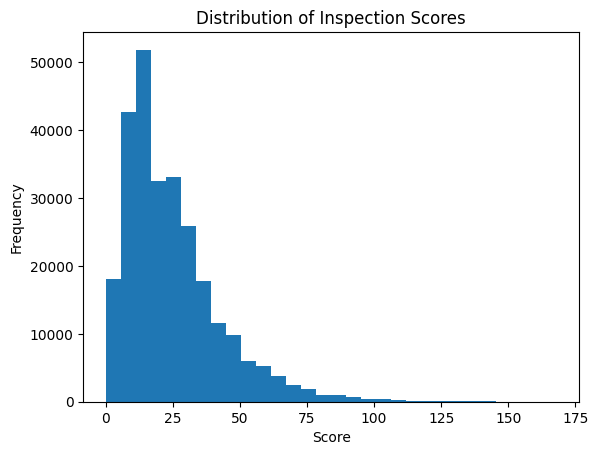

In [40]:
plt.figure()
plt.hist(df['SCORE'], bins=30)
plt.title('Distribution of Inspection Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

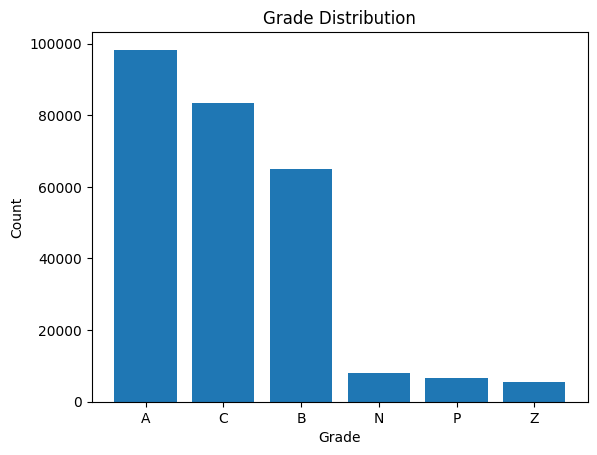

In [41]:
grade_counts = df['GRADE'].value_counts()
plt.figure()
plt.bar(grade_counts.index, grade_counts.values)
plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

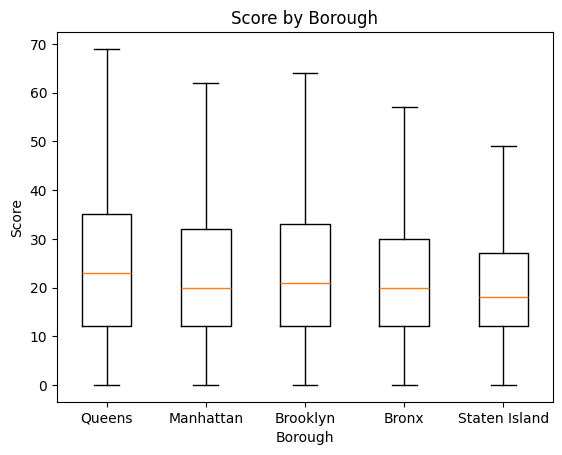

In [42]:
boros = df['BORO'].unique()
data_by_boro = [df[df['BORO'] == b]['SCORE'] for b in boros]
plt.figure()
plt.boxplot(data_by_boro, labels=boros, showfliers=False)
plt.title('Score by Borough')
plt.xlabel('Borough')
plt.ylabel('Score')
plt.show()

In [43]:
df['CUISINE DESCRIPTION'].value_counts()

,count
CUISINE DESCRIPTION,
American,42763
Chinese,26929
Coffee/Tea,18624
Pizza,16265
Latin American,11610
...,...
Nuts/Confectionary,30
Czech,13
Haute Cuisine,5


In [44]:
# 5) Top 10 Cuisine Types
top_cuisines = df['CUISINE DESCRIPTION'].value_counts().head(10)

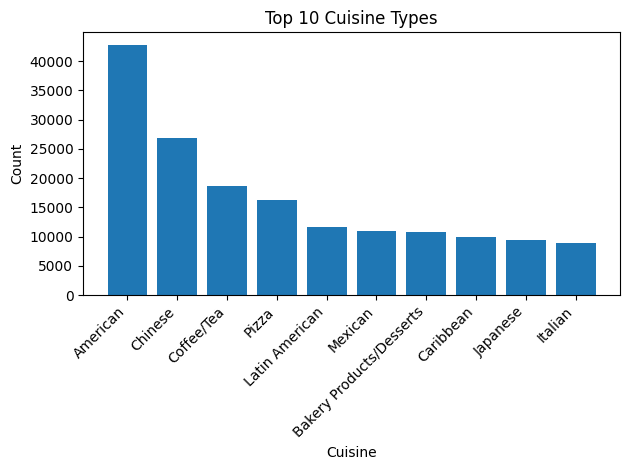

In [45]:
plt.figure()
plt.bar(top_cuisines.index, top_cuisines.values)
plt.title('Top 10 Cuisine Types')
plt.xlabel('Cuisine')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

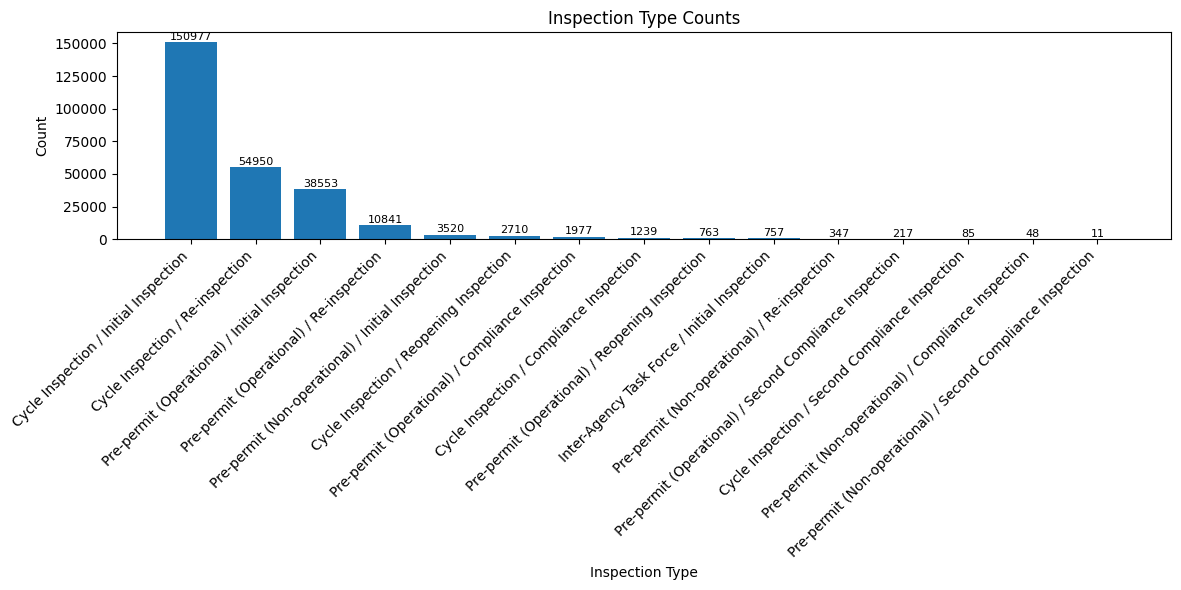

In [46]:

ins_type_counts = df['INSPECTION TYPE'].value_counts()

plt.figure(figsize=(12,6))
bars = plt.bar(ins_type_counts.index, ins_type_counts.values)
plt.title('Inspection Type Counts')
plt.xlabel('Inspection Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')


for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 100,
             f'{int(h)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


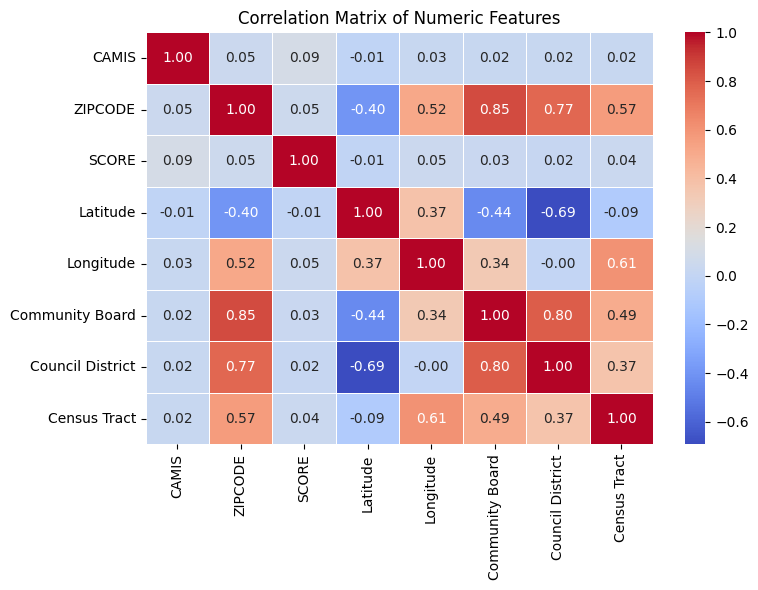

In [47]:

corr = df.select_dtypes(include=['float64','int64']).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


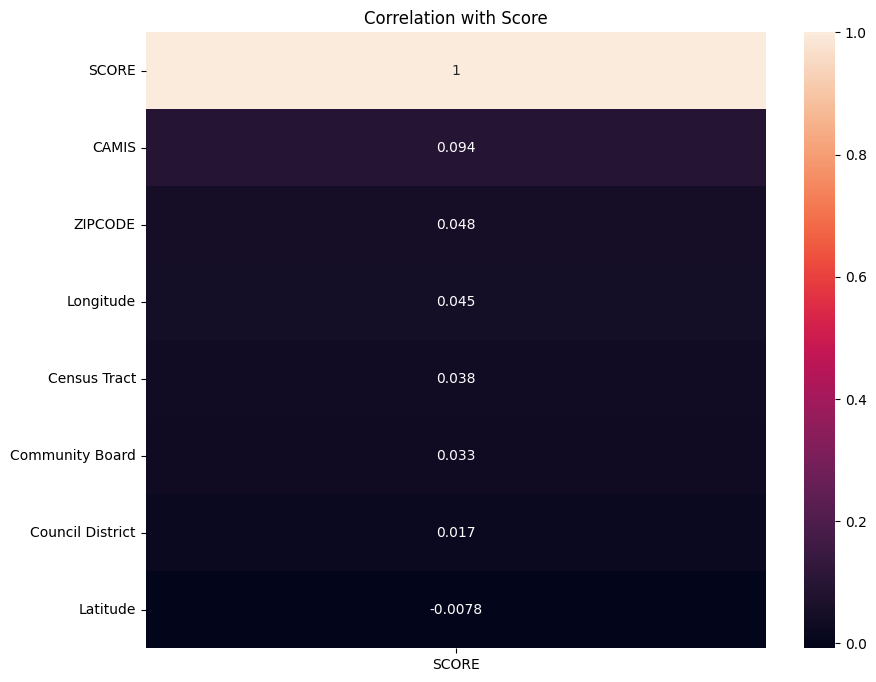

In [48]:
corr = df.select_dtypes(include=['float64','int64']).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr[['SCORE']].sort_values('SCORE', ascending=False), annot=True)
plt.title('Correlation with Score')
plt.show()


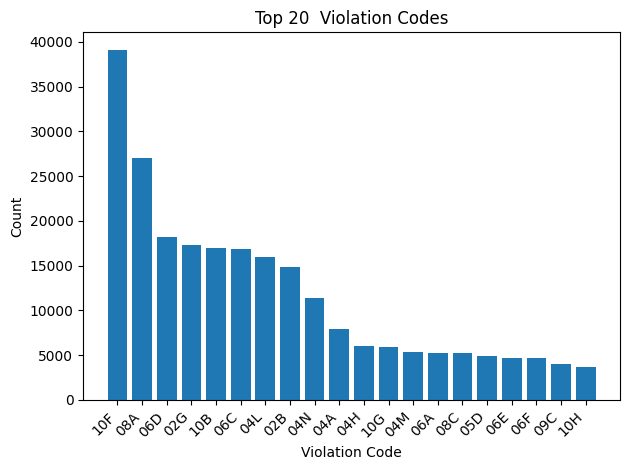

In [49]:
top_viols = df['VIOLATION CODE'].value_counts().head(20)
plt.figure()
plt.bar(top_viols.index, top_viols.values)
plt.title('Top 20  Violation Codes')
plt.xlabel('Violation Code')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

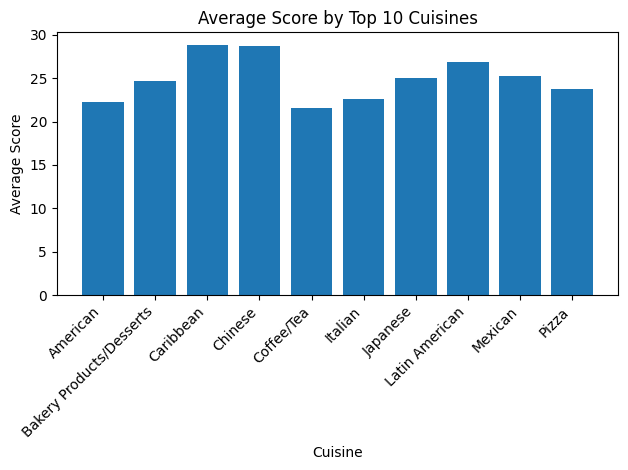

In [50]:

# Average Score by Top 10 Cuisines
top_cuisines = df['CUISINE DESCRIPTION'].value_counts().head(10).index
avg_score_cuisine = df[df['CUISINE DESCRIPTION'].isin(top_cuisines)].groupby('CUISINE DESCRIPTION')['SCORE'].mean()
plt.figure()
plt.bar(avg_score_cuisine.index, avg_score_cuisine.values)
plt.title('Average Score by Top 10 Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## متوسط نتائج التفتيش حسب يوم الأسبوع

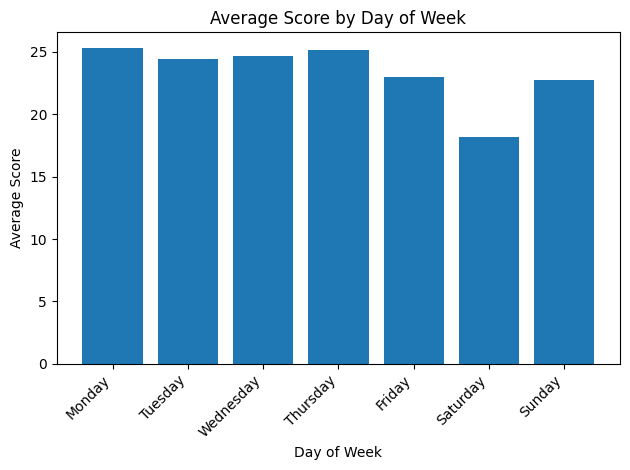

In [51]:
df['DayOfWeek'] = df['INSPECTION DATE'].dt.day_name()
avg_score_dow = df.groupby('DayOfWeek')['SCORE'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure()
plt.bar(avg_score_dow.index, avg_score_dow.values)
plt.title('Average Score by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


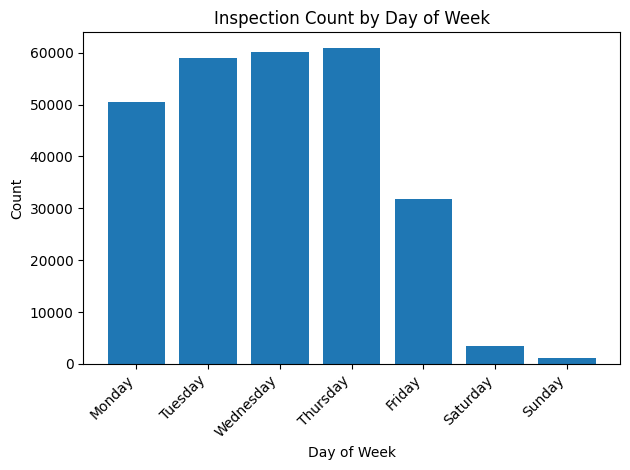

In [52]:
count_dow = df['DayOfWeek'].value_counts().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.figure()
plt.bar(count_dow.index, count_dow.values)
plt.title('Inspection Count by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


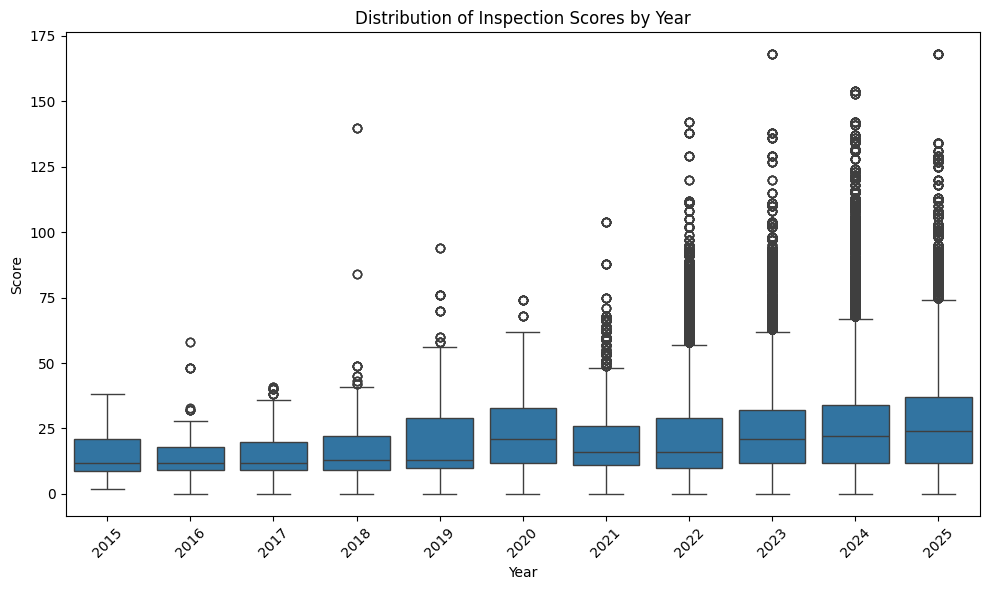

In [53]:
df['Year'] = df['INSPECTION DATE'].dt.year
plt.figure(figsize=(10,6))
sns.boxplot(x='Year', y='SCORE', data=df, showfliers=True)
plt.title('Distribution of Inspection Scores by Year')
plt.xlabel('Year')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

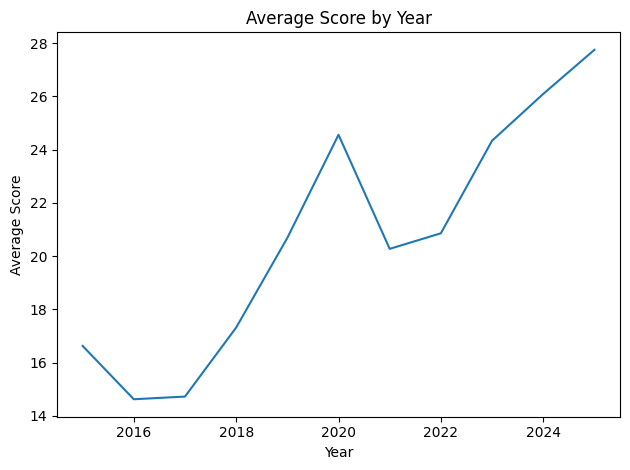

In [54]:
avg_score_year = df.groupby('Year')['SCORE'].mean()
plt.figure()
plt.plot(avg_score_year.index, avg_score_year.values)
plt.title('Average Score by Year')
plt.xlabel('Year')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

## عرض المتوسط الشهري لنتائج التفتيش

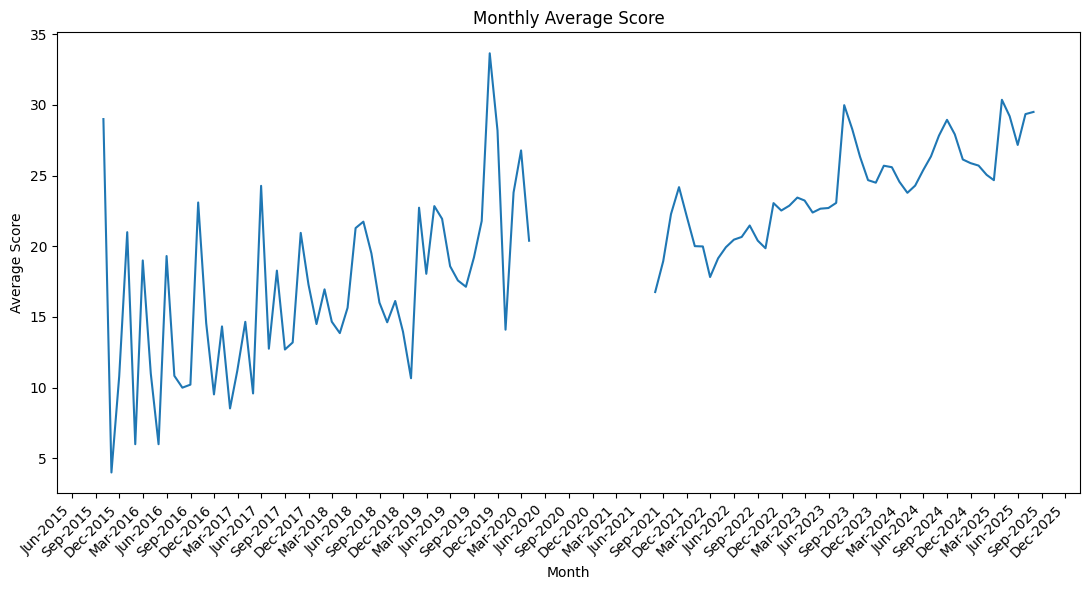

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
monthly_avg = df.set_index('INSPECTION DATE')['SCORE'].resample('M').mean()


fig, ax = plt.subplots(figsize=(11,6))
ax.plot(monthly_avg.index, monthly_avg.values)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))

# 6) Rotate and style
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Monthly Average Score')
ax.set_xlabel('Month')
ax.set_ylabel('Average Score')
plt.tight_layout()
plt.show()

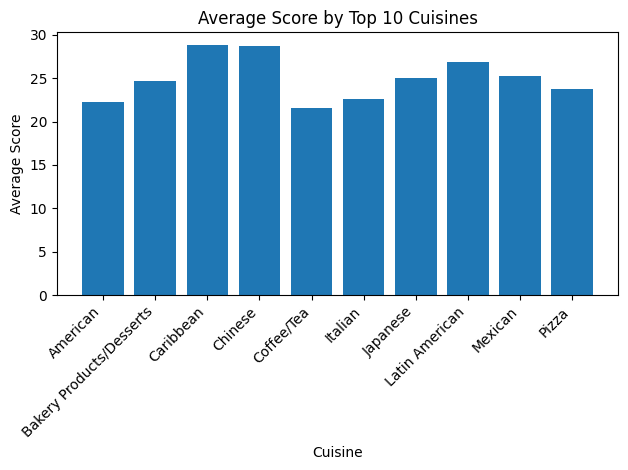

In [56]:

# Average Score by Top 10 Cuisines
top_cuisines = df['CUISINE DESCRIPTION'].value_counts().head(10).index
avg_score_cuisine = df[df['CUISINE DESCRIPTION'].isin(top_cuisines)].groupby('CUISINE DESCRIPTION')['SCORE'].mean()
plt.figure()
plt.bar(avg_score_cuisine.index, avg_score_cuisine.values)
plt.title('Average Score by Top 10 Cuisines')
plt.xlabel('Cuisine')
plt.ylabel('Average Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


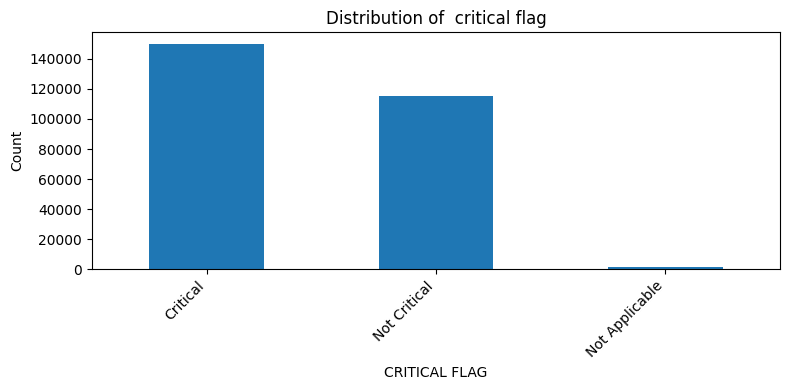

In [57]:

counts = df['CRITICAL FLAG'].value_counts()
plt.figure(figsize=(8,4))
counts.plot(kind='bar')
plt.title(f'Distribution of  critical flag')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

-  الغالبية Critical فهذا يعني
  
  المطاعم لا تلتزم بأساسيات السلامة الغذائية


In [58]:
df['FLAG_CRITICAL'] = (df['CRITICAL FLAG']=='Critical').astype(int)


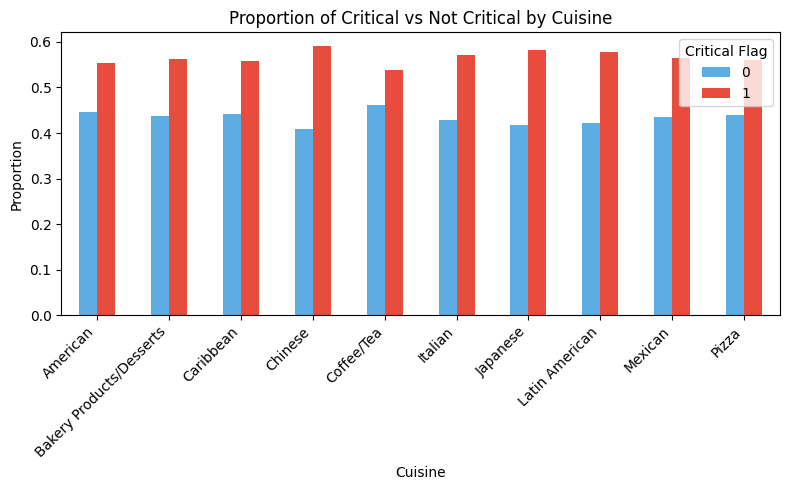

In [59]:
import pandas as pd
import matplotlib.pyplot as plt


top_cuisines = df['CUISINE DESCRIPTION'].value_counts().head(10).index

df_top = df[df['CUISINE DESCRIPTION'].isin(top_cuisines)]

ct = pd.crosstab(
    df_top['CUISINE DESCRIPTION'],
    df_top['FLAG_CRITICAL'],
    normalize='index'
)

ct.plot(
    kind='bar',
    stacked=False,
    figsize=(8,5),
    color=['#5DADE2','#E74C3C']
)
plt.title('Proportion of Critical vs Not Critical by Cuisine')
plt.xlabel('Cuisine')
plt.ylabel('Proportion')
plt.legend(title='Critical Flag', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


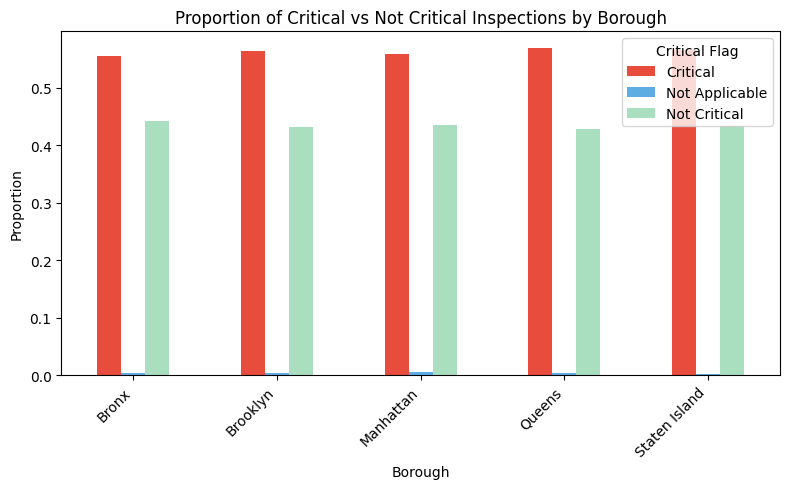

In [60]:
import pandas as pd
import matplotlib.pyplot as plt


top_boros = df['BORO'].unique()

df_boro = df[df['BORO'].isin(top_boros)]


ct_boro = pd.crosstab(
    df_boro['BORO'],
    df_boro['CRITICAL FLAG'],
    normalize='index'
)


ax = ct_boro.plot(
    kind='bar',
    stacked=False,
    figsize=(8,5),
    color=['#E74C3C', '#5DADE2', '#A9DFBF']  # Critical, Not Critical, Not Applicable
)

ax.set_title('Proportion of Critical vs Not Critical Inspections by Borough')
ax.set_xlabel('Borough')
ax.set_ylabel('Proportion')
ax.legend(title='Critical Flag', loc='upper right')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


In [61]:
import pandas as pd

cat_cols = ['BORO','CUISINE DESCRIPTION','INSPECTION TYPE','CRITICAL FLAG','FLAG_CRITICAL','GRADE']
dummies = pd.get_dummies(df[cat_cols], drop_first=True)

corr_with_score = dummies.corrwith(df['SCORE']).abs().sort_values(ascending=False)

print(corr_with_score.head(10))


GRADE_C                                                          0.734405
GRADE_P                                                          0.204766
FLAG_CRITICAL                                                    0.147476
CRITICAL FLAG_Not Critical                                       0.134798
INSPECTION TYPE_Pre-permit (Operational) / Initial Inspection    0.118009
CRITICAL FLAG_Not Applicable                                     0.092527
GRADE_B                                                          0.083864
CUISINE DESCRIPTION_Chinese                                      0.074965
CUISINE DESCRIPTION_Donuts                                       0.074260
INSPECTION TYPE_Cycle Inspection / Re-inspection                 0.068522
dtype: float64


In [62]:
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    cm = pd.crosstab(x, y)
    chi2 = chi2_contingency(cm)[0]
    n = cm.sum().sum()
    phi2 = chi2 / n
    r, k = cm.shape
    return np.sqrt(phi2 / min(r-1, k-1))

cat_cols = ['BORO','CUISINE DESCRIPTION','INSPECTION TYPE','CRITICAL FLAG','FLAG_CRITICAL','GRADE']
cramers = pd.DataFrame(index=cat_cols, columns=cat_cols)

for c1 in cat_cols:
    for c2 in cat_cols:
        cramers.loc[c1, c2] = cramers_v(df[c1], df[c2])

print(cramers.astype(float))


                         BORO  CUISINE DESCRIPTION  INSPECTION TYPE  \
BORO                 1.000000             0.224396         0.027578   
CUISINE DESCRIPTION  0.224396             1.000000         0.070346   
INSPECTION TYPE      0.027578             0.070346         1.000000   
CRITICAL FLAG        0.016236             0.048085         0.445059   
FLAG_CRITICAL        0.010070             0.052685         0.076236   
GRADE                0.040257             0.119207         0.249701   

                     CRITICAL FLAG  FLAG_CRITICAL     GRADE  
BORO                      0.016236       0.010070  0.040257  
CUISINE DESCRIPTION       0.048085       0.052685  0.119207  
INSPECTION TYPE           0.445059       0.076236  0.249701  
CRITICAL FLAG             1.000000       1.000000  0.221828  
FLAG_CRITICAL             1.000000       0.999992  0.169100  
GRADE                     0.221828       0.169100  1.000000  


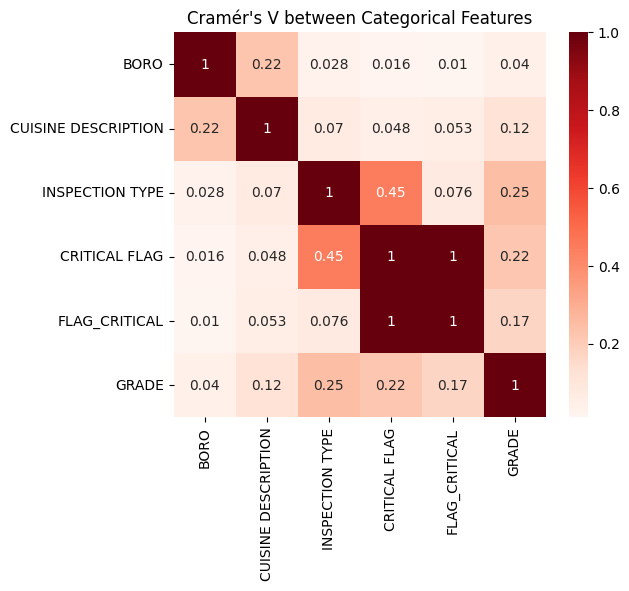

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cramers.astype(float), annot=True, cmap='Reds')
plt.title("Cramér's V between Categorical Features")
plt.show()


In [64]:
df['VIOLATION CODE'].value_counts()

,count
VIOLATION CODE,
10F,39109
08A,27012
06D,18181
02G,17328
10B,17013
...,...
18-11,3
04I,2
22G,2


In [65]:
counts = df['VIOLATION CODE'].value_counts(normalize=True)
rare_codes = counts[counts < 0.01].index
df['VIOLATION_CODE_GROUPED'] = df['VIOLATION CODE'].replace(rare_codes, 'Other')

##  التجميع على مستوى زيارة التفتيش (مطعم + تاريخ)

In [66]:
group_cols = ['CAMIS','INSPECTION DATE']
agg = df.groupby(group_cols).agg(
    violation_count=('VIOLATION_CODE_GROUPED','count'),
    critical_count =('CRITICAL FLAG', lambda x: (x=='Critical').sum()),
    SCORE         =('SCORE','first'),
    BORO           =('BORO','first'),
    ZIPCODE        =('ZIPCODE','first'),
    Latitude       =('Latitude','first'),
    Longitude      =('Longitude','first'),
    INSPECTION_TYPE=('INSPECTION TYPE','first'),
    Critical_Flag  =('CRITICAL FLAG','first'),

).reset_index()

agg.rename(columns={'Critical_Flag':'FLAG_CRITICAL'}, inplace=True)


In [67]:
agg['year']       = agg['INSPECTION DATE'].dt.year
agg['month']      = agg['INSPECTION DATE'].dt.month
agg['day']        = agg['INSPECTION DATE'].dt.day
agg['dayofweek']  = agg['INSPECTION DATE'].dt.dayofweek
agg['is_weekend'] = (agg['dayofweek'] >= 5).astype(int)

In [68]:
def season_of(month):
    if month in [12,1,2]:   return 'winter'
    if month in [3,4,5]:    return 'spring'
    if month in [6,7,8]:    return 'summer'
    return 'autumn'

agg['season']   = agg['month'].apply(season_of)
agg['is_summer'] = (agg['season']=='summer').astype(int)

In [69]:
agg['FLAG_CRITICAL'] = (agg['FLAG_CRITICAL']=='Critical').astype(int)

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA


desc = (
    df.groupby(group_cols)['VIOLATION DESCRIPTION']
      .apply(lambda texts: " ".join(texts.dropna()))
      .rename('joined_description')
)
agg = agg.merge(desc, on=group_cols)


In [71]:
agg.shape

(80006, 19)

In [72]:
agg.describe().T

,count,mean,min,25%,50%,75%,max,std
CAMIS,80006.0,47733132.226408,30075445.0,41694199.0,50077010.0,50117964.0,50172718.0,3943310.428154
INSPECTION DATE,80006,2023-10-02 21:04:48.068394496,2015-09-24 00:00:00,2022-12-02 00:00:00,2023-11-21 00:00:00,2024-09-26 00:00:00,2025-07-03 00:00:00,NaN
violation_count,80006.0,3.337187,1.0,2.0,3.0,4.0,19.0,2.010978
critical_count,80006.0,1.876559,0.0,1.0,1.0,3.0,13.0,1.495734
SCORE,80006.0,17.383171,0.0,9.0,12.0,23.0,168.0,14.465042
ZIPCODE,80006.0,10693.893258,10000.0,10022.0,10474.0,11229.0,11697.0,593.166928
Latitude,80006.0,40.726633,40.499563,40.686033,40.731164,40.761104,40.912822,0.068337
Longitude,80006.0,-73.943749,-74.248708,-73.989612,-73.959423,-73.902958,-73.700928,0.076134
FLAG_CRITICAL,80006.0,0.532435,0.0,0.0,1.0,1.0,1.0,0.49895
year,80006.0,2023.287928,2015.0,2022.0,2023.0,2024.0,2025.0,1.234968


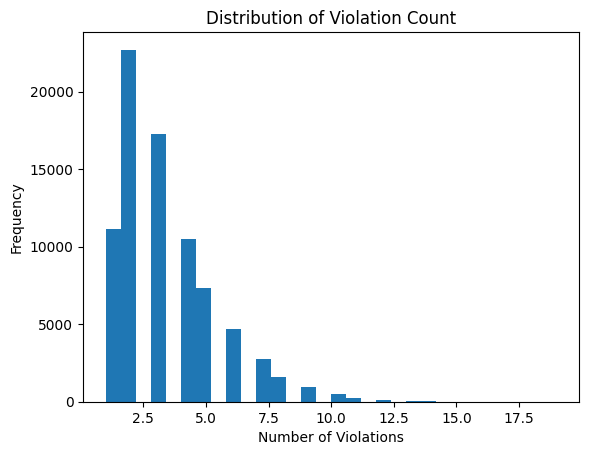

In [73]:
plt.figure()
plt.hist(agg['violation_count'], bins=30)
plt.title('Distribution of Violation Count')
plt.xlabel('Number of Violations')
plt.ylabel('Frequency')
plt.show()


In [74]:
bins = [0, 2, 5, 10, np.inf]
labels = ['Low','Medium','High','Very High']
agg['viol_level'] = pd.cut(agg['violation_count'], bins=bins, labels=labels)



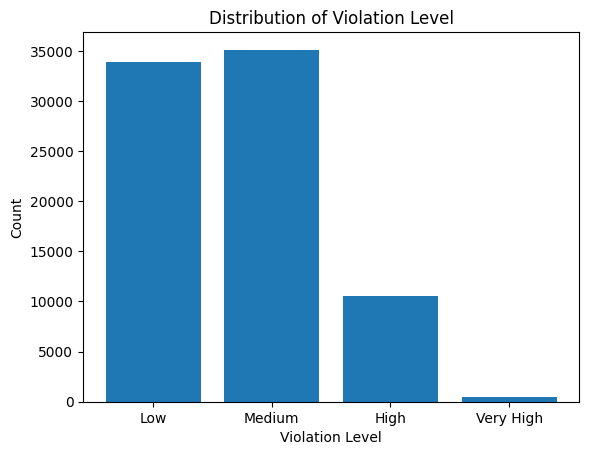

In [75]:
import matplotlib.pyplot as plt

viol_level_counts = agg['viol_level'].value_counts().reindex(labels)

plt.figure()
plt.bar(viol_level_counts.index, viol_level_counts.values)
plt.title('Distribution of Violation Level')
plt.xlabel('Violation Level')
plt.ylabel('Count')
plt.show()

معظم زيارات التفتيش تسجل مخالفات قليلة إلى متوسطة بينما
المخالفات الكثيرة جدا نادرة لكنها قد تشكل خطرا صحيا كبيرا عند حدوثها

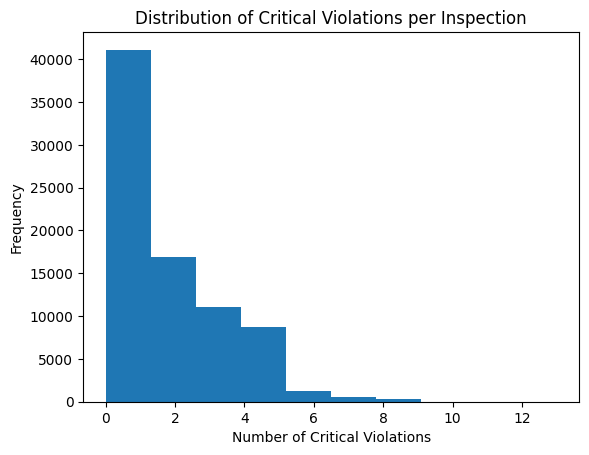

In [76]:
plt.figure()
plt.hist(agg['critical_count'], bins=10)
plt.title('Distribution of Critical Violations per Inspection')
plt.xlabel('Number of Critical Violations')
plt.ylabel('Frequency')
plt.show()

 معظم التفتيشات آمنة من ناحية الخروقات الحرجة
 وجود مخالفة حرجة واحدة شائع، وأكثر من ذلك نادر

In [77]:
agg['has_critical'] = (agg['critical_count'] > 0).astype(int)

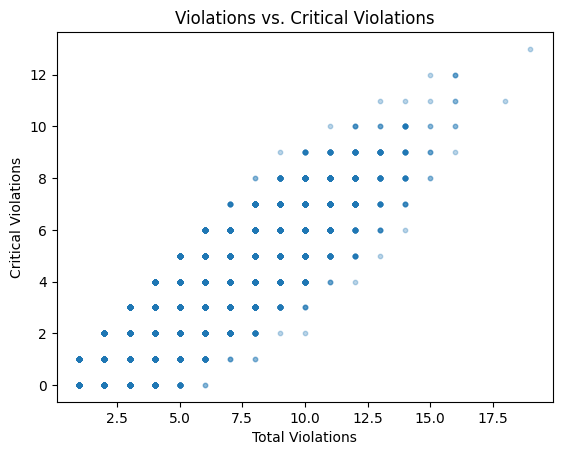

In [78]:
plt.figure()
plt.scatter(agg['violation_count'], agg['critical_count'], alpha=0.3, s=10)
plt.title('Violations vs. Critical Violations')
plt.xlabel('Total Violations')
plt.ylabel('Critical Violations')
plt.show()

كلما زاد العدد الكلّي للمخالفات في تفتيش، زاد عدد المخالفات الحرِجة

## انشاء عمود معدل خطورة المخالفات
viol_ratio

وهو نسبة المخالفات الحرجة إلى إجمالي المخالفات + 1

In [79]:
agg['viol_ratio'] = agg['critical_count'] / (agg['violation_count'] + 1)

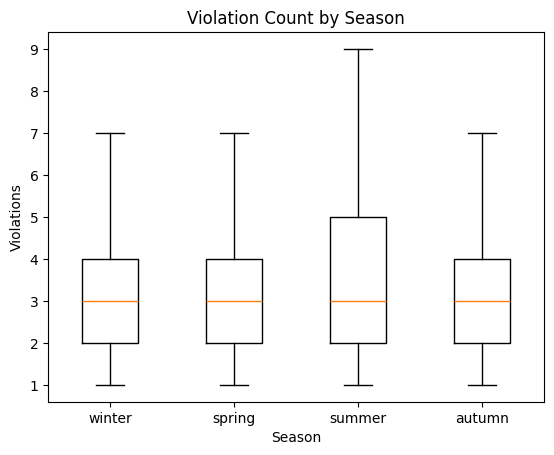

In [80]:

seasons = ['winter','spring','summer','autumn']
data_by_season = [agg[agg['season']==s]['violation_count'] for s in seasons]
plt.figure()
plt.boxplot(data_by_season, labels=seasons, showfliers=False)
plt.title('Violation Count by Season')
plt.xlabel('Season')
plt.ylabel('Violations')
plt.show()

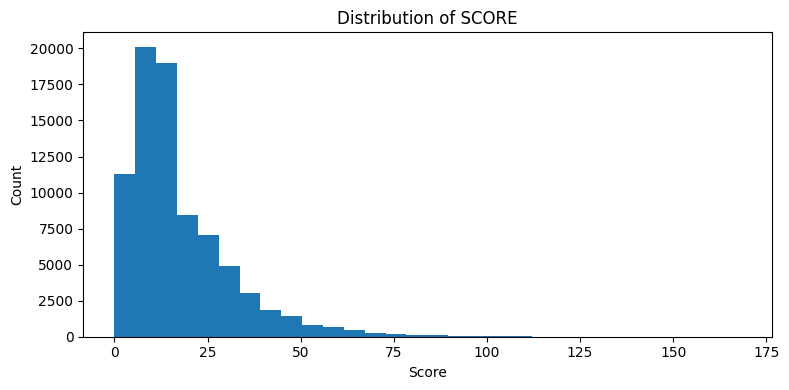

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(agg['SCORE'], bins=30)
plt.title('Distribution of SCORE')
plt.xlabel('Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



عدد الزيارات ينخفض بشدة كلما ارتفع السكور

المخالفات الكبيرة أو الكثيرة نادرة

يوجد عدد قليل جدًا من الزيارات تجاوزت الدرجة 60 أو 100

عظم المطاعم تؤدي أداء جيدا نسبيا بينما هناك حالات قليلة جدا لمطاعم بها مخالفات كثيرة وتحتاج إلى متابعة أو تدخل

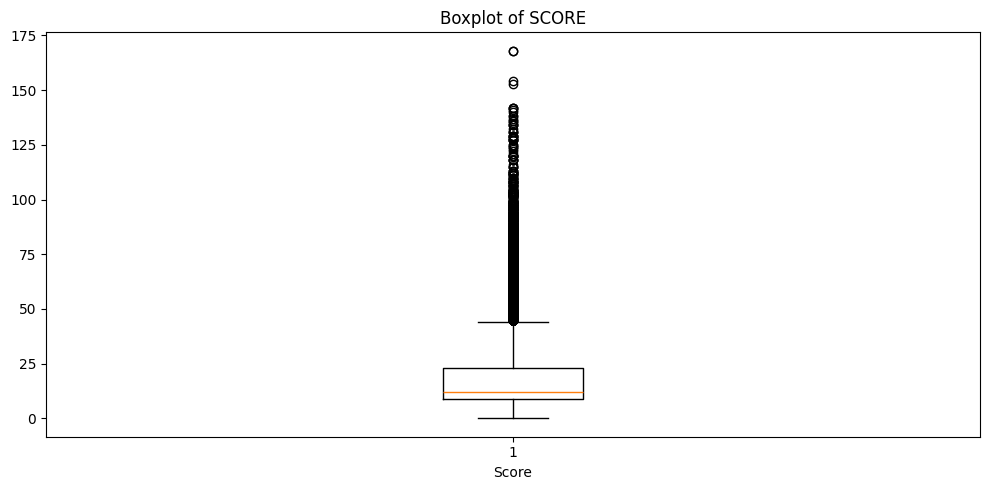

In [82]:
plt.figure(figsize=(10,5))
plt.boxplot(agg['SCORE'])
plt.title('Boxplot of SCORE')
plt.xlabel('Score')
plt.tight_layout()
plt.show()

معظم المطاعم تؤدي أداءً جيدًا درجات منخفضة
لكن هناك عدد قليل من المطاعم سجّلت مخالفات كثيرة ويجب متابعتها

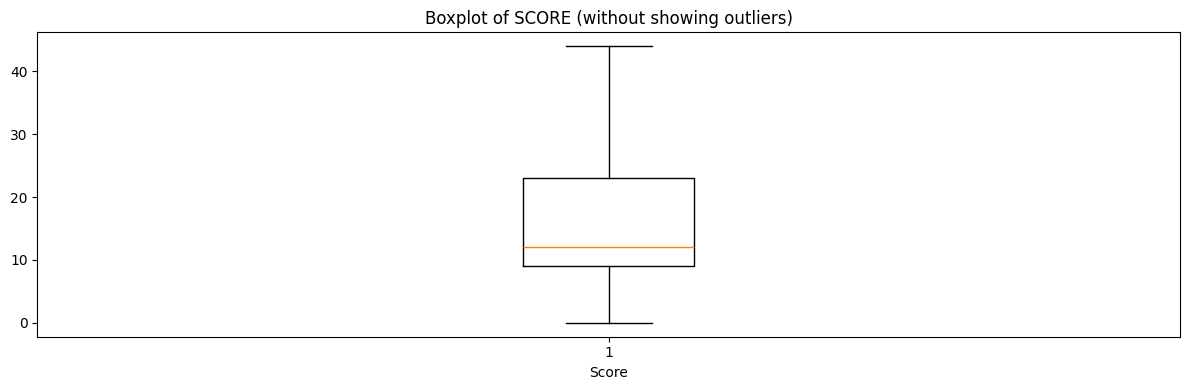

In [83]:
plt.figure(figsize=(12,4))

plt.boxplot(agg['SCORE'], showfliers=False)
plt.title('Boxplot of SCORE (without showing outliers)')
plt.xlabel('Score')
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Monthly Total Violations'}, xlabel='INSPECTION DATE'>

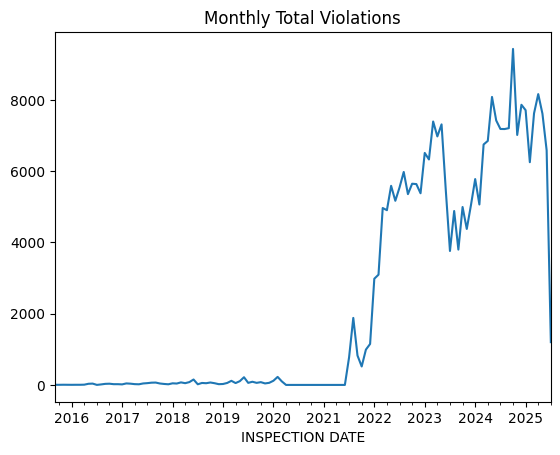

In [84]:
ts = agg.set_index('INSPECTION DATE')['violation_count'].resample('M').sum()
ts.plot(title="Monthly Total Violations")


بعد جائحة كورونا، ارتفع عدد المخالفات المسجلة بشكل واضح ما قد يشير إلى زيادة الرقابة أو تدهور الالتزام الصحي في بعض الفترات

In [85]:
agg['days_since_last'] = (
    agg.sort_values(['CAMIS','INSPECTION DATE'])
       .groupby('CAMIS')['INSPECTION DATE']
       .diff().dt.days.fillna(0)
)

In [86]:
agg.columns

Index(['CAMIS', 'INSPECTION DATE', 'violation_count', 'critical_count',
       'SCORE', 'BORO', 'ZIPCODE', 'Latitude', 'Longitude', 'INSPECTION_TYPE',
       'FLAG_CRITICAL', 'year', 'month', 'day', 'dayofweek', 'is_weekend',
       'season', 'is_summer', 'joined_description', 'viol_level',
       'has_critical', 'viol_ratio', 'days_since_last'],
      dtype='object')

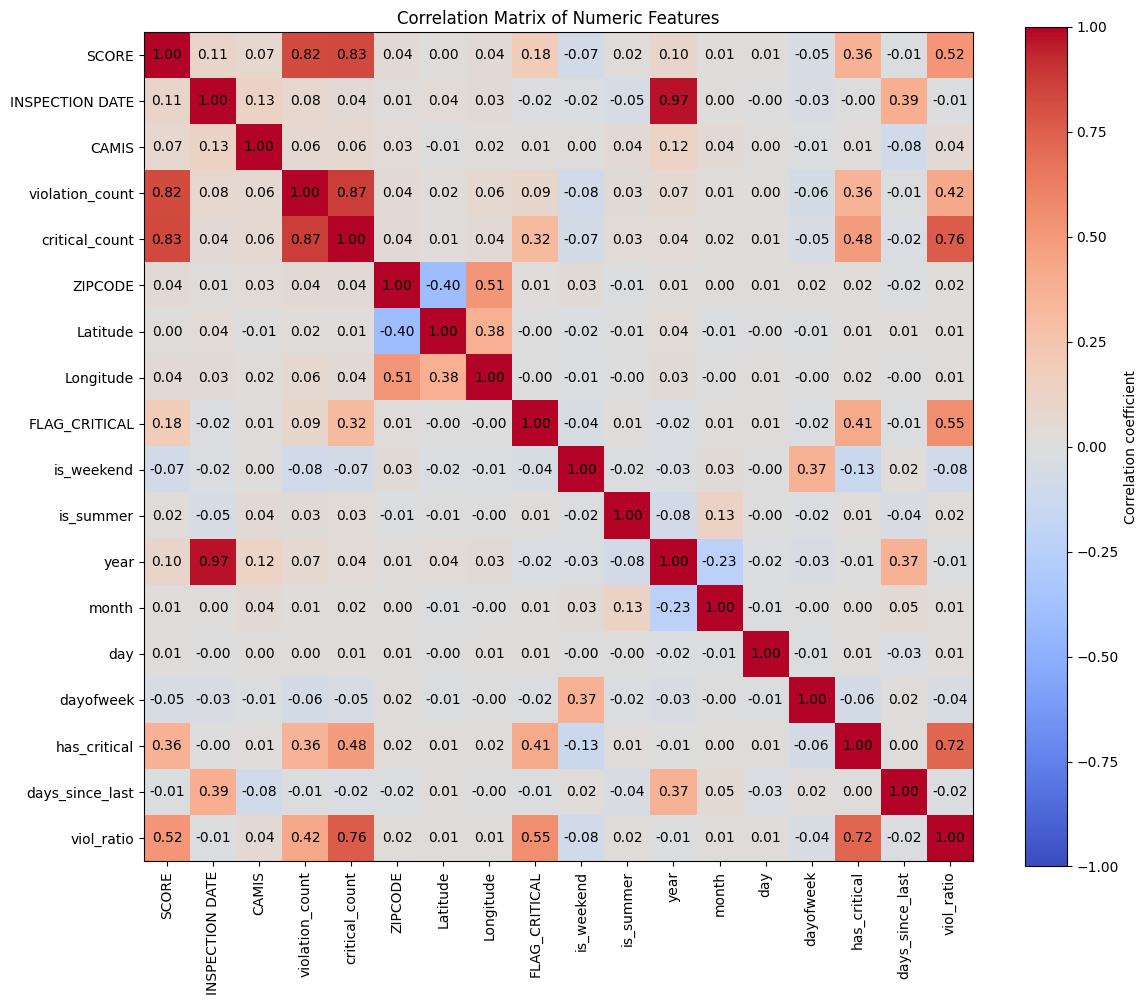

In [87]:
import matplotlib.pyplot as plt


numeric_cols = ['SCORE','INSPECTION DATE','CAMIS','violation_count', 'critical_count', 'ZIPCODE', 'Latitude', 'Longitude','FLAG_CRITICAL', 'is_weekend', 'is_summer','year', 'month', 'day', 'dayofweek' , 'has_critical','days_since_last','viol_ratio']

corr = agg[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12,10))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)


ax.set_xticks(np.arange(len(numeric_cols)))
ax.set_yticks(np.arange(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=90)
ax.set_yticklabels(numeric_cols)


for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha='center', va='center', color='black')

fig.colorbar(cax, ax=ax, label='Correlation coefficient')
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

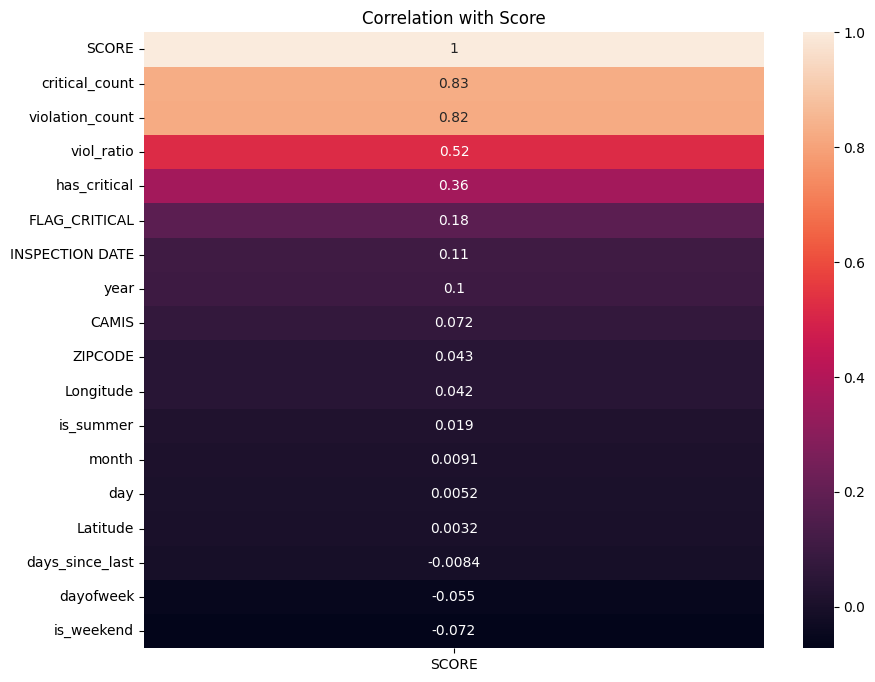

In [88]:
plt.figure(figsize=(10,8))
sns.heatmap(corr[['SCORE']].sort_values('SCORE', ascending=False), annot=True)
plt.title('Correlation with Score')
plt.show()

In [89]:
agg['ZIP3'] = agg['ZIPCODE'].astype(str).str[:3]

In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

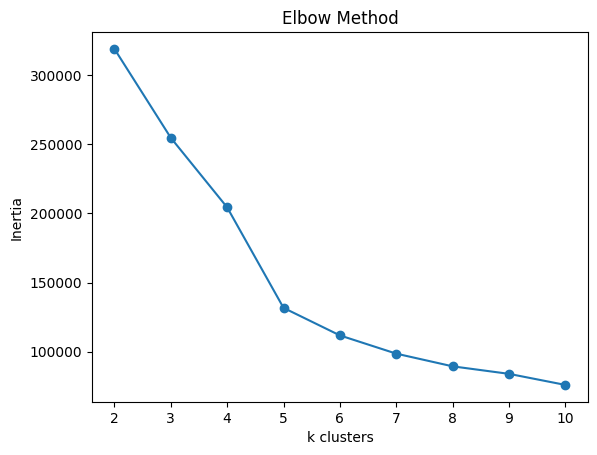

In [91]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


features = agg[['violation_count','critical_count','year','is_summer','is_weekend']]


sc = StandardScaler()
X_sc = sc.fit_transform(features)

inertia = []
for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42).fit(X_sc)
    inertia.append(km.inertia_)
plt.plot(range(2,11), inertia, marker='o')
plt.xlabel('k clusters'); plt.ylabel('Inertia'); plt.title('Elbow Method'); plt.show()

In [92]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

agg['cluster'] = clusters
print(agg.groupby('cluster')[['violation_count','critical_count','SCORE']].mean())


         violation_count  critical_count      SCORE
cluster                                            
0               2.411071        1.135787  11.689635
1               6.662092        4.287776  38.408021
2               2.822490        1.604717  13.992213
3               2.858769        1.534540  14.227901
4               2.343750        1.242560  10.897321


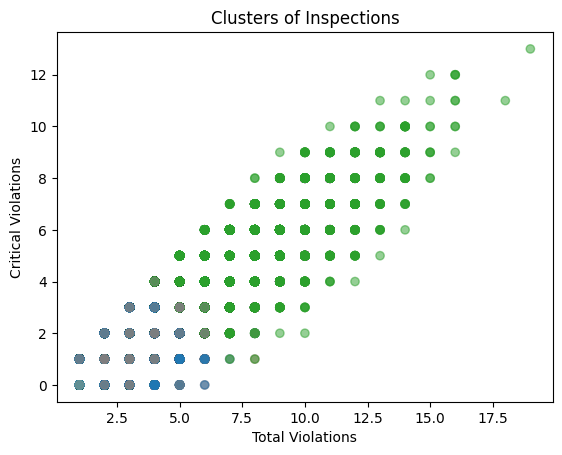

In [93]:
import matplotlib.pyplot as plt

plt.scatter(agg['violation_count'], agg['critical_count'],
            c=agg['cluster'], cmap='tab10', alpha=0.5)
plt.xlabel('Total Violations')
plt.ylabel('Critical Violations')
plt.title('Clusters of Inspections')
plt.show()


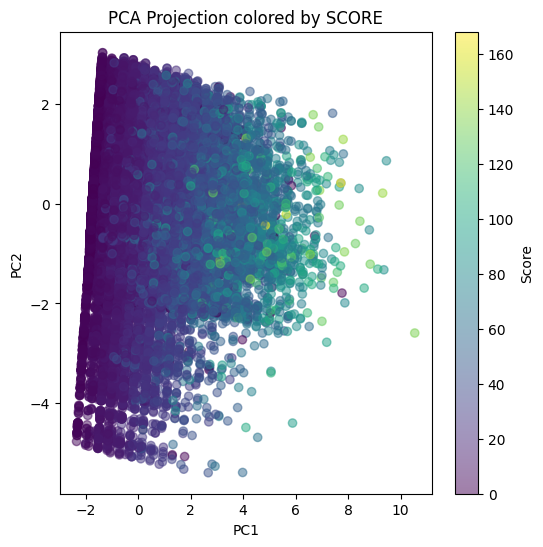

In [94]:
from sklearn.decomposition import PCA

features = ['violation_count','critical_count','Latitude','Longitude']  # مثال
sc = StandardScaler()
Xn = sc.fit_transform(agg[features])

pca2 = PCA(n_components=2, random_state=42)
pcs = pca2.fit_transform(Xn)

plt.figure(figsize=(6,6))
plt.scatter(pcs[:,0], pcs[:,1], c=agg['SCORE'], cmap='viridis', alpha=0.5)
plt.colorbar(label='Score')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA Projection colored by SCORE')
plt.show()


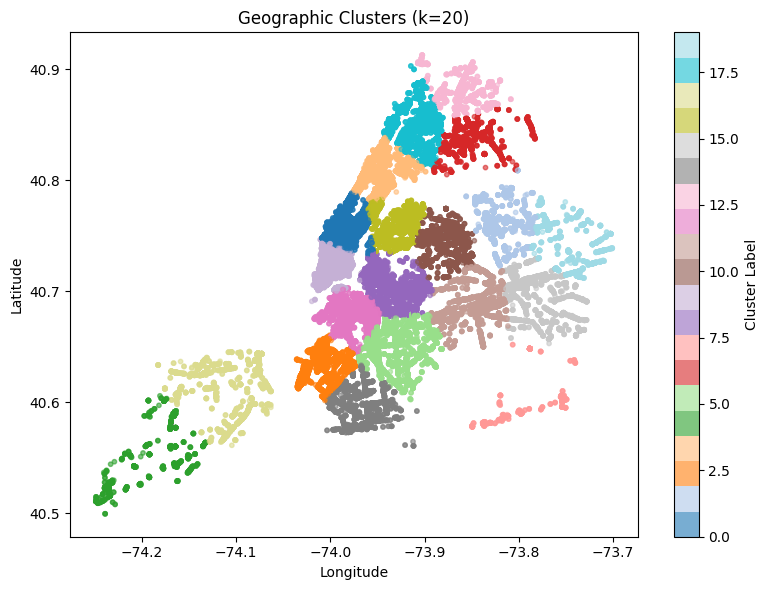

In [95]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

coords = agg[['Latitude', 'Longitude']]

scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

kmeans = KMeans(n_clusters=20, random_state=42)
clusters = kmeans.fit_predict(coords_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    coords['Longitude'], coords['Latitude'],
    c=clusters, cmap='tab20', s=10, alpha=0.6
)
plt.title('Geographic Clusters (k=20)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster Label')
plt.tight_layout()
plt.show()


In [96]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

transactions = (
    df.groupby(['CAMIS','INSPECTION DATE'])['VIOLATION CODE']
      .apply(lambda x: list(set(x.dropna())))
      .tolist()
)

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_apriori = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(df_apriori, min_support=0.01, use_colnames=True)
rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.2)

rules.sort_values('lift', ascending=False).head(10)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
563,"(04L, 02G)","(08A, 02B)",0.048384,0.069645,0.014686,0.303539,4.358391,1.0,0.011317,1.335833,0.809736,0.142114,0.251403,0.257207
566,"(08A, 02B)","(04L, 02G)",0.069645,0.048384,0.014686,0.210876,4.358391,1.0,0.011317,1.205914,0.828240,0.142114,0.170754,0.257207
689,"(04M, 02G)","(08A, 10F)",0.019399,0.131953,0.010949,0.564433,4.277543,1.0,0.008389,1.992914,0.781379,0.077985,0.498222,0.323706
688,"(08A, 10F)","(04M, 02G)",0.131953,0.019399,0.010949,0.082978,4.277543,1.0,0.008389,1.069333,0.882695,0.077985,0.064837,0.323706
686,"(08A, 02G)","(04M, 10F)",0.081594,0.032048,0.010949,0.134191,4.187246,1.0,0.008334,1.117975,0.828805,0.106621,0.105525,0.237922
691,"(04M, 10F)","(08A, 02G)",0.032048,0.081594,0.010949,0.341654,4.187246,1.0,0.008334,1.395020,0.786381,0.106621,0.283164,0.237922
564,"(04L, 02B)","(08A, 02G)",0.043559,0.081594,0.014686,0.337159,4.132163,1.0,0.011132,1.385561,0.792517,0.132949,0.278271,0.258577
565,"(08A, 02G)","(04L, 02B)",0.081594,0.043559,0.014686,0.179994,4.132163,1.0,0.011132,1.166382,0.825339,0.132949,0.142648,0.258577
700,"(04N, 10F)","(08A, 02G)",0.052596,0.081594,0.017224,0.327471,4.013432,1.0,0.012932,1.365602,0.792520,0.147254,0.267722,0.269281
701,"(08A, 02G)","(04N, 10F)",0.081594,0.052596,0.017224,0.211091,4.013432,1.0,0.012932,1.200903,0.817543,0.147254,0.167294,0.269281


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

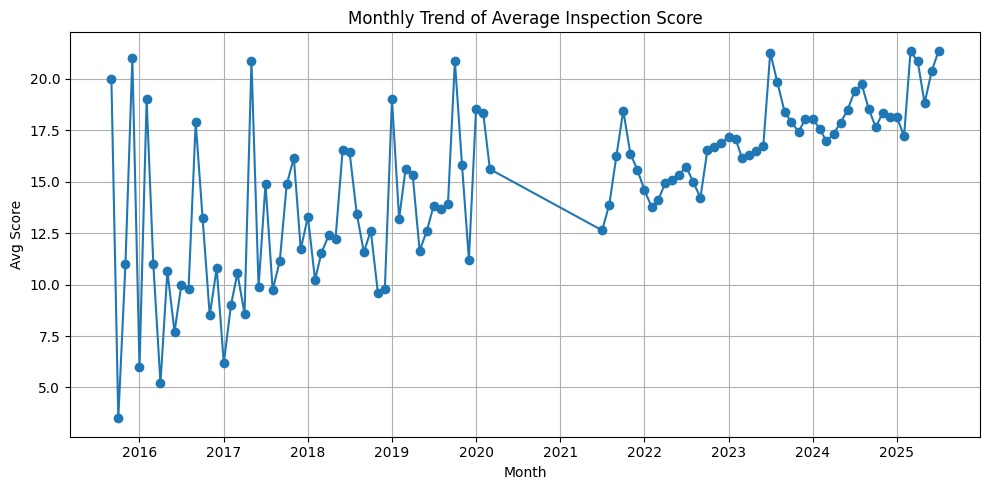

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [97]:
monthly_score = agg.groupby(['year','month'])['SCORE'].mean().reset_index()
monthly_score['Date'] = pd.to_datetime(monthly_score[['year','month']].assign(day=1))

plt.figure(figsize=(10,5))
plt.plot(monthly_score['Date'], monthly_score['SCORE'], marker='o')
plt.title("Monthly Trend of Average Inspection Score")
plt.xlabel("Month")
plt.ylabel("Avg Score")
plt.grid()
plt.tight_layout()
plt.show()


In [98]:
repeaters = (
    df[df['CRITICAL FLAG'] == 'Critical']
    .groupby('CAMIS')
    .size()
    .reset_index(name='critical_count')
    .query('critical_count >= 3')
    .sort_values('critical_count', ascending=False)
)

print("Top repeat violators:")
print(repeaters.head(10))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Top repeat violators:
          CAMIS  critical_count
60     40365904              47
3574   41406895              45
12493  50089474              45
7932   50040296              44
16794  50117697              43
15723  50111296              42
17818  50123073              41
17187  50119363              40
9176   50056245              39
17473  50120714              39


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

## إعداد البيانات للتدريب

In [100]:

feature_cols_to_drop = ['CAMIS', 'INSPECTION DATE', 'SCORE']

X = agg.drop(columns=feature_cols_to_drop)
y = agg['SCORE']

print(f"X: {X.shape}")
print(f"columns: {list(X.columns)}")

X: (80006, 22)
columns: ['violation_count', 'critical_count', 'BORO', 'ZIPCODE', 'Latitude', 'Longitude', 'INSPECTION_TYPE', 'FLAG_CRITICAL', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'season', 'is_summer', 'joined_description', 'viol_level', 'has_critical', 'viol_ratio', 'days_since_last', 'ZIP3', 'cluster']


In [101]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (64004, 22), Test: (16002, 22)


In [102]:
from sklearn.base import BaseEstimator, TransformerMixin

class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, column):
        self.column = column
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.column].fillna('NoViolation')


class GeoCluster(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=20):
        self.n_clusters = n_clusters
        self.scaler_ = StandardScaler()
        self.km_ = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    def fit(self, X, y=None):
        coords = X[['Latitude', 'Longitude']].values
        self.scaler_.fit(coords)
        self.km_.fit(self.scaler_.transform(coords))
        return self
    def transform(self, X):
        coords = X[['Latitude', 'Longitude']].values
        return self.km_.predict(self.scaler_.transform(coords)).reshape(-1, 1)

print("Transformers done ")

Transformers done 


In [103]:

numeric_cols = [
    'violation_count', 'critical_count', 'FLAG_CRITICAL',
    'year', 'month', 'day', 'dayofweek',
    'is_weekend', 'is_summer', 'has_critical', 'viol_ratio', 'days_since_last',
    'ZIPCODE', 'ZIP3'
]

numeric_cols_final = [c for c in numeric_cols if c != 'ZIP3']
categorical_cols = ['BORO', 'INSPECTION_TYPE', 'season', 'viol_level']


X_train = X_train.copy()
X_test  = X_test.copy()
X_train['ZIP3'] = X_train['ZIP3'].astype(str).str[:3].str.extract(r'(\d+)').fillna(0).astype(int)
X_test['ZIP3']  = X_test['ZIP3'].astype(str).str[:3].str.extract(r'(\d+)').fillna(0).astype(int)
numeric_cols_final.append('ZIP3')

print("Numeric cols:", numeric_cols_final)
print("Categorical cols:", categorical_cols)

Numeric cols: ['violation_count', 'critical_count', 'FLAG_CRITICAL', 'year', 'month', 'day', 'dayofweek', 'is_weekend', 'is_summer', 'has_critical', 'viol_ratio', 'days_since_last', 'ZIPCODE', 'ZIP3']
Categorical cols: ['BORO', 'INSPECTION_TYPE', 'season', 'viol_level']


In [ ]:
from sklearn.pipeline import FeatureUnion


text_pipeline = Pipeline([
    ('selector', ColumnSelector('joined_description')),
    ('tfidf', TfidfVectorizer(min_df=0.01, max_df=0.90, ngram_range=(1,2))),
    ('svd',   TruncatedSVD(n_components=50, random_state=42)),
])

tabular_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols_final),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('geo', GeoCluster(n_clusters=20), ['Latitude', 'Longitude']),
], remainder='drop')

print("Pipelines done")

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
import scipy.sparse as sp

class CombinedFeatures(BaseEstimator, TransformerMixin):

    def __init__(self, tabular_prep, text_pipe):
        self.tabular_prep = tabular_prep
        self.text_pipe    = text_pipe
    def fit(self, X, y=None):
        self.tabular_prep.fit(X, y)
        self.text_pipe.fit(X, y)
        return self
    def transform(self, X):
        tab  = self.tabular_prep.transform(X)
        text = self.text_pipe.transform(X)
        if sp.issparse(tab):  tab  = tab.toarray()
        if sp.issparse(text): text = text.toarray()
        return np.hstack([tab, text])

combined_prep = CombinedFeatures(tabular_preprocessor, text_pipeline)
print("CombinedFeatures ready")

## تدريب وتقييم النماذج

In [106]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name=""):

    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    r2_tr  = r2_score(y_tr, y_pred_tr)
    r2_te  = r2_score(y_te, y_pred_te)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred_te))
    mae    = mean_absolute_error(y_te, y_pred_te)

    print(f"{'='*45}")
    print(f"  {name}")
    print(f"  Train R²: {r2_tr:.3f}  |  Test R²: {r2_te:.3f}")
    print(f"  RMSE: {rmse:.3f}       |  MAE: {mae:.3f}")
    return {'model': name, 'R²_train': r2_tr, 'R²_test': r2_te, 'RMSE': rmse, 'MAE': mae}

results = []

### Linear Regression

In [107]:
lr_pipe = Pipeline([
    ('prep',  combined_prep),
    ('model', LinearRegression())
])
results.append(evaluate_model(lr_pipe, X_train, y_train, X_test, y_test, "Linear Regression"))

  Linear Regression
  Train R²: 0.800  |  Test R²: 0.800
  RMSE: 6.539       |  MAE: 3.261


### Ridge Regression

In [108]:
ridge_pipe = Pipeline([
    ('prep',  combined_prep),
    ('model', Ridge(alpha=1.0))
])
results.append(evaluate_model(ridge_pipe, X_train, y_train, X_test, y_test, "Ridge Regression"))

  Ridge Regression
  Train R²: 0.800  |  Test R²: 0.800
  RMSE: 6.539       |  MAE: 3.258


### Decision Tree Regressor

In [109]:
dtr_pipe = Pipeline([
    ('prep',  combined_prep),
    ('model', DecisionTreeRegressor(max_depth=5, random_state=42))
])
results.append(evaluate_model(dtr_pipe, X_train, y_train, X_test, y_test, "Decision Tree"))

  Decision Tree
  Train R²: 0.758  |  Test R²: 0.757
  RMSE: 7.198       |  MAE: 3.785


### KNN Regressor

In [110]:
knn_pipe = Pipeline([
    ('prep',  combined_prep),
    ('model', KNeighborsRegressor(n_neighbors=20))
])
results.append(evaluate_model(knn_pipe, X_train, y_train, X_test, y_test, "KNN Regressor"))

  KNN Regressor
  Train R²: 0.735  |  Test R²: 0.706
  RMSE: 7.928       |  MAE: 4.333


### XGBoost Regressor

In [111]:
xgb_pipe = Pipeline([
    ('prep',  combined_prep),
    ('model', XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0
    ))
])
results.append(evaluate_model(xgb_pipe, X_train, y_train, X_test, y_test, "XGBoost Regressor"))

  XGBoost Regressor
  Train R²: 0.878  |  Test R²: 0.833
  RMSE: 5.972       |  MAE: 2.815


### LightGBM Regressor

In [112]:
lgb_pipe = Pipeline([
    ('prep',  combined_prep),
    ('model', LGBMRegressor(num_leaves=20, learning_rate=0.03, n_estimators=300, verbose=-1))
])
results.append(evaluate_model(lgb_pipe, X_train, y_train, X_test, y_test, "LightGBM Regressor"))

  LightGBM Regressor
  Train R²: 0.859  |  Test R²: 0.830
  RMSE: 6.022       |  MAE: 2.868


In [113]:

cat_pipe = Pipeline([
    ('prep',  combined_prep),
    ('model', CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        l2_leaf_reg=3, random_state=42, verbose=0
    ))
])
results.append(evaluate_model(cat_pipe, X_train, y_train, X_test, y_test, "CatBoost Regressor"))

  CatBoost Regressor
  Train R²: 0.864  |  Test R²: 0.835
  RMSE: 5.939       |  MAE: 2.820


### Random Forest Regressor

In [114]:
rf_pipe = Pipeline([
    ('prep',  combined_prep),
    ('model', RandomForestRegressor(
        n_estimators=200, max_depth=8,
        min_samples_leaf=4, random_state=42, n_jobs=-1
    ))
])
results.append(evaluate_model(rf_pipe, X_train, y_train, X_test, y_test, "Random Forest"))

  Random Forest
  Train R²: 0.833  |  Test R²: 0.806
  RMSE: 6.441       |  MAE: 3.118


In [115]:
from sklearn.model_selection import cross_val_score

best_pipe = Pipeline([
    ('prep',  CombinedFeatures(
        ColumnTransformer([
            ('num', StandardScaler(), numeric_cols_final),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
            ('geo', GeoCluster(n_clusters=20), ['Latitude', 'Longitude']),
        ], remainder='drop'),
        Pipeline([
            ('selector', ColumnSelector('joined_description')),
            ('tfidf', TfidfVectorizer(min_df=0.01, max_df=0.90, ngram_range=(1,2))),
            ('svd',   TruncatedSVD(n_components=50, random_state=42)),
        ])
    )),
    ('model', CatBoostRegressor(
        iterations=500, learning_rate=0.05, depth=6,
        l2_leaf_reg=3, random_state=42, verbose=0
    ))
])

cv_r2  = cross_val_score(best_pipe, X, y, cv=5, scoring='r2', n_jobs=-1)
cv_rmse = np.sqrt(-cross_val_score(best_pipe, X, y, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
cv_mae  = -cross_val_score(best_pipe, X, y, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)

for i, (r2, rmse, mae) in enumerate(zip(cv_r2, cv_rmse, cv_mae), 1):
    print(f"Fold {i}: R²={r2:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}")

print(f"\nMean CV R²  : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"Mean CV RMSE: {cv_rmse.mean():.3f}")
print(f"Mean CV MAE : {cv_mae.mean():.3f}")

Fold 1: R²=0.804, RMSE=5.416, MAE=2.506
Fold 2: R²=0.790, RMSE=6.035, MAE=2.769
Fold 3: R²=0.785, RMSE=6.416, MAE=3.017
Fold 4: R²=0.824, RMSE=6.120, MAE=2.906
Fold 5: R²=0.876, RMSE=6.131, MAE=3.028

Mean CV R²  : 0.816 ± 0.033
Mean CV RMSE: 6.024
Mean CV MAE : 2.845


## Optuna — Hyperparameter Tuning

In [117]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 6.4 MB/s eta 0:00:00


In [118]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def make_cat_pipe(params):
    return Pipeline([
        ('prep', CombinedFeatures(
            ColumnTransformer([
                ('num', StandardScaler(), numeric_cols_final),
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
                ('geo', GeoCluster(n_clusters=20), ['Latitude', 'Longitude']),
            ], remainder='drop'),
            Pipeline([
                ('selector', ColumnSelector('joined_description')),
                ('tfidf', TfidfVectorizer(min_df=0.01, max_df=0.90, ngram_range=(1,2))),
                ('svd',   TruncatedSVD(n_components=50, random_state=42)),
            ])
        )),
        ('model', CatBoostRegressor(**params, verbose=0, random_state=42, allow_writing_files=False))
    ])

def objective(trial):
    params = {
        'iterations':    trial.suggest_int('iterations', 200, 600, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.2, log=True),
        'depth':         trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg':   trial.suggest_float('l2_leaf_reg', 1.0, 10.0, log=True),
    }
    pipe = make_cat_pipe(params)

    scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(f"==> Best R²: {study.best_value:.3f}")
print("==> Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

==> Best R²: 0.830
==> Best hyperparameters:
    iterations: 600
    learning_rate: 0.15905525510092575
    depth: 5
    l2_leaf_reg: 3.101473565635549


## النموذج النهائي بأفضل المعاملات

In [120]:
final_pipe = make_cat_pipe({**study.best_params})
final_pipe.fit(X_train, y_train)

y_pred_test  = final_pipe.predict(X_test)
y_pred_train = final_pipe.predict(X_train)

r2_test  = r2_score(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
rmse     = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae      = mean_absolute_error(y_test, y_pred_test)

print("===(CatBoost - Optuna Tuned) ===")
print(f"Train R² : {r2_train:.3f}")
print(f"Test  R² : {r2_test:.3f}")
print(f"Test RMSE: {rmse:.3f}")
print(f"Test MAE : {mae:.3f}")

===(CatBoost - Optuna Tuned) ===
Train R² : 0.892
Test  R² : 0.832
Test RMSE: 5.993
Test MAE : 2.840


## (Residual Analysis)

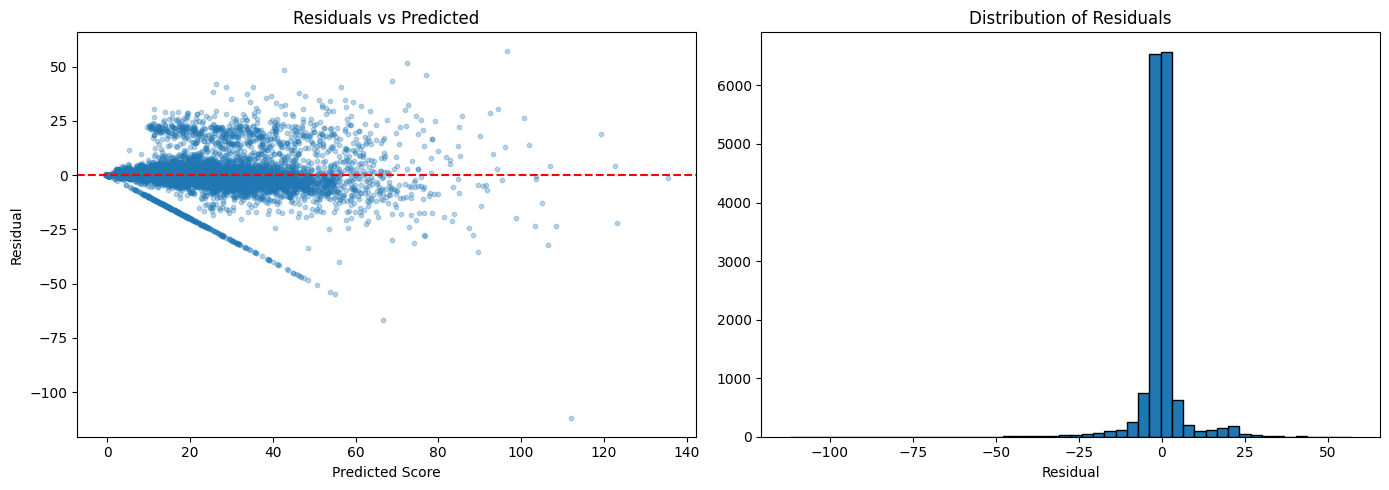

Mean Residual: -0.0100
Std  Residual: 5.9927


In [121]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred_test, residuals, alpha=0.3, s=10)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Score')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual')
axes[1].set_title('Distribution of Residuals')

plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std  Residual: {residuals.std():.4f}")

In [122]:
results_df = pd.DataFrame(results).sort_values('R²_test', ascending=False)
results_df = results_df.round(3)
print(results_df.to_string(index=False))

             model  R²_train  R²_test  RMSE   MAE
CatBoost Regressor     0.864    0.835 5.939 2.820
 XGBoost Regressor     0.878    0.833 5.972 2.815
LightGBM Regressor     0.859    0.830 6.022 2.868
     Random Forest     0.833    0.806 6.441 3.118
  Ridge Regression     0.800    0.800 6.539 3.258
 Linear Regression     0.800    0.800 6.539 3.261
     Decision Tree     0.758    0.757 7.198 3.785
     KNN Regressor     0.735    0.706 7.928 4.333


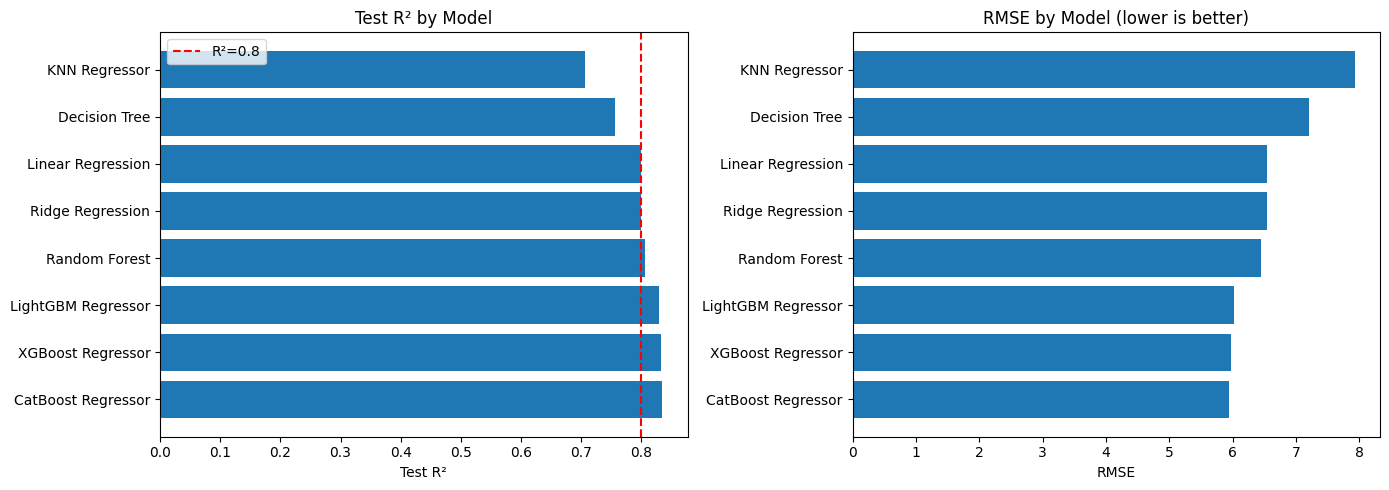

In [123]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(results_df['model'], results_df['R²_test'])
axes[0].set_xlabel('Test R²')
axes[0].set_title('Test R² by Model')
axes[0].axvline(0.8, color='red', linestyle='--', label='R²=0.8')
axes[0].legend()

axes[1].barh(results_df['model'], results_df['RMSE'])
axes[1].set_xlabel('RMSE')
axes[1].set_title('RMSE by Model (lower is better)')

plt.tight_layout()
plt.show()